In [1]:
# =============================================================================
# SOURCE/notebooks/05_text_preprocessing.py
# Notebook: Phần 3 - Tiền xử lý văn bản – RAGTruth dataset
# Ngôn ngữ: Tiếng Việt (markdown) + Python (code)
#
# FEEDBACK từ leader (FeedbackFromLeader.pdf - trang 7-8):
# [🔴 P1-CRITICAL] Pipeline chuẩn hóa (§3.1): đang gộp tất cả bước vào 1 hàm
#   Cần bảng per-step vocab change:
#   | Bước | Vocab trước | Vocab sau | Thay đổi |
#   | original | xx | - | - |
#   | lowercase | - | yy | -Z% |
#   | remove HTML | - | zz | -W% |
#   | remove URL | ... | ... | ... |
#   | remove punct | ... | ... | ... |
#   | normalize ws | ... | ... | ... |
# [🟡 P2] §2.3.2: word cloud per label - KIỂM TRA đã có chưa
# [🟡 P2] §2.3.1: tính ký tự nhưng không vẽ - [NEW] đã vẽ trong subplot 2x2
# [🟡 P2] §2.3.3.b MI: cần report average MI, không chỉ top-20
#          → [NEW] ĐÃ CÓ MI mean section sau top-20
# [🟡 P2] §3.4 Stemming: cần 5-fold CV + collision table
#          → [NEW] ĐÃ CÓ 5-fold trong code (cần verify kết quả)
# [🟡 P2] §3.5 Vectorization: cần impact report + statistical test
# =============================================================================
#

# PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU VĂN BẢN
## Dataset: RAGTruth (wandb/RAGTruth-processed)

**Mô tả:** RAGTruth là tập dữ liệu đánh giá ảo giác (hallucination) trong hệ thống RAG (Retrieval-Augmented Generation). Tập dữ liệu chứa ~18.000 mẫu văn bản tiếng Anh với 2 nhãn:
- **Supported**: Văn bản được hỗ trợ bởi ngữ cảnh (không chứa ảo giác)
- **Hallucinated**: Văn bản chứa thông tin bịa đặt hoặc mâu thuẫn với ngữ cảnh

**Nguồn:** https://huggingface.co/datasets/wandb/RAGTruth-processed

---

**Checklist đối chiếu Requirement (§2.3 + §3.1):**
- **§2.3.1** ≥10.000 mẫu, ≥2 nhãn — kiểm tra assert sau khi tạo `df`.
- **§2.3.2** Mann–Whitney; word cloud + **bảng top-50** + TTR; Zipf log–log.
- **§2.3.3** Chuẩn hóa + đo từ vựng; 4 kiểu token; stop+MI+NB; stem/lemma+collision+LR; BoW/TF-IDF n-gram/Word2Vec + sparsity + cosine + t-SNE + silhouette; **§2.3.3.f** MiniLM + K-Means + Linear SVM.
- **§3.1** Lý thuyết (markdown) → code → phân tích; thư viện gồm scipy, **statsmodels**, sklearn, …


## 0. Cài đặt thư viện và Import

In [2]:
# Cài đặt thư viện cần thiết (%pip + đủ gói Requirement §3.1)
%pip install nltk spacy wordcloud gensim scikit-learn matplotlib seaborn tokenizers sentence-transformers statsmodels imbalanced-learn missingno pyarrow -q
!python -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import json as _json
import scipy.sparse as sp_io
from sklearn.model_selection import train_test_split
import importlib.util
from sentence_transformers import SentenceTransformer
from itertools import combinations
from scipy.sparse import csr_matrix
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers.models import BPE
from tokenizers import Tokenizer
from gensim.models import Word2Vec
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    silhouette_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import statsmodels.api as sm
from scipy.stats import mannwhitneyu
from scipy import stats
import missingno as msno  # dùng để đối chiếu đủ thư viện theo Requirement §3.1
from wordcloud import WordCloud
import spacy
from nltk.stem import PorterStemmer, SnowballStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import nltk
from pathlib import Path
import os
import string
import re
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')


# NLP

# Visualization

# Stats

# ML / Vectorization

# Word2Vec

# Subword tokenizer

# KHÔNG import datasets ở đây — dataset đã tải sẵn qua download_text_dataset.py

# NLTK downloads
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

# spaCy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# Style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Random seed
SEED = 42
np.random.seed(SEED)

# Thư mục output: Kaggle / local


def _resolve_output_dir() -> Path:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None:
        p = Path('/kaggle/working') / 'data' / 'processed'
    else:
        cwd = Path.cwd()
        if (cwd / 'data').is_dir():
            p = cwd / 'data' / 'processed'
        elif (cwd.parent / 'data').is_dir():
            p = cwd.parent / 'data' / 'processed'
        else:
            p = cwd / 'data' / 'processed'
    p.mkdir(parents=True, exist_ok=True)
    return p


OUTPUT_DIR = _resolve_output_dir()
print(f'OUTPUT_DIR = {OUTPUT_DIR}')
print('All libraries imported successfully!')

c:\Users\admin\Downloads\Lab1DataMining\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\admin\Downloads\Lab1DataMining\.venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


OUTPUT_DIR = C:\Users\admin\Downloads\Lab1DataMining\data\processed
All libraries imported successfully!


## 1. Tải và Chuẩn bị Dữ liệu

**Lưu ý:** Dataset đã được tải về local bằng `download_text_dataset.py`.
Nếu chưa tải, chạy: `python DataMining-Lab1/download_text_dataset.py`

In [4]:
# Load dataset từ local parquet (không cần kết nối internet)


def _find_data_root() -> Path:
    """Tìm thư mục data/text/raw/ chứa ragtruth_full.parquet."""
    candidates = [
        Path.cwd() / 'data' / 'text' / 'raw',
        Path.cwd().parent / 'data' / 'text' / 'raw',
        Path.cwd().parent.parent / 'data' / 'text' / 'raw',
    ]
    try:
        candidates += [
            Path(__file__).resolve().parent.parent / 'data' / 'text' / 'raw',
            Path(__file__).resolve().parent.parent.parent /
            'data' / 'text' / 'raw',
        ]
    except NameError:
        pass
    candidates += [
        Path.cwd() / 'data' / 'raw',
        Path.cwd().parent / 'data' / 'raw',
    ]
    for p in candidates:
        if (p / 'ragtruth_full.parquet').exists():
            return p
    raise FileNotFoundError(
        "Không tìm thấy ragtruth_full.parquet!\n"
        "Hãy chạy: python DataMining-Lab1/download_text_dataset.py"
    )


DATA_RAW = _find_data_root()
df = pd.read_parquet(DATA_RAW / 'ragtruth_full.parquet')

print(f"Tải thành công: {DATA_RAW / 'ragtruth_full.parquet'}")
print(f"Dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label_name'].value_counts())
print(f"\nLabel ratio:")
print(df['label_name'].value_counts(normalize=True).round(4))
df.head(3)

Tải thành công: C:\Users\admin\Downloads\Lab1DataMining\data\text\raw\ragtruth_full.parquet
Dataset shape: (17790, 16)

Label distribution:
label_name
Supported       10126
Hallucinated     7664
Name: count, dtype: int64

Label ratio:
label_name
Supported       0.5692
Hallucinated    0.4308
Name: proportion, dtype: float64


,id,query,context,output,task_type,quality,model,temperature,hallucination_labels,hallucination_labels_processed,input_str,evident_conflict,baseless_info,label,label_name,text
0,0,Summarize the following news within 116 words:,"Seventy years ago, Anne Frank died of typhus i...",The Anne Frank House has revealed that Anne Fr...,Summary,good,gpt-4-0613,0.7,[],"{'baseless_info': 0, 'evident_conflict': 0}",Below is the original news:\n{'question': 'Sum...,0,0,0,Supported,The Anne Frank House has revealed that Anne Fr...
1,1,Summarize the following news within 116 words:,"Seventy years ago, Anne Frank died of typhus i...",New research released by the Anne Frank House ...,Summary,good,gpt-3.5-turbo-0613,0.7,[],"{'baseless_info': 0, 'evident_conflict': 0}",Below is the original news:\n{'question': 'Sum...,0,0,0,Supported,New research released by the Anne Frank House ...
2,2,Summarize the following news within 116 words:,"Seventy years ago, Anne Frank died of typhus i...",New research conducted by the Anne Frank House...,Summary,good,mistral-7B-instruct,0.7,"[{""start"": 636, ""end"": 653, ""text"": ""February ...","{'baseless_info': 1, 'evident_conflict': 1}",Below is the original news:\n{'question': 'Sum...,1,1,1,Hallucinated,New research conducted by the Anne Frank House...


#### Đối chiếu §2.3.1 — Quy mô dữ liệu

Đề: **≥ 10.000 mẫu**, **≥ 2 nhãn**. Cell dưới lưu biến `N_SAMPLES`, `N_LABELS` và `assert`.

In [5]:
N_SAMPLES = len(df)
N_LABELS = df['label'].nunique()
LABEL_NAMES = df['label_name'].unique().tolist()
print("=" * 60)
print("KIỂM TRA §2.3.1")
print(f"Mẫu: {N_SAMPLES:,} (≥10.000) | Nhãn: {N_LABELS} (≥2) | {LABEL_NAMES}")
assert N_SAMPLES >= 10_000
assert N_LABELS >= 2
print("=> OK")

KIỂM TRA §2.3.1
Mẫu: 17,790 (≥10.000) | Nhãn: 2 (≥2) | ['Supported', 'Hallucinated']
=> OK


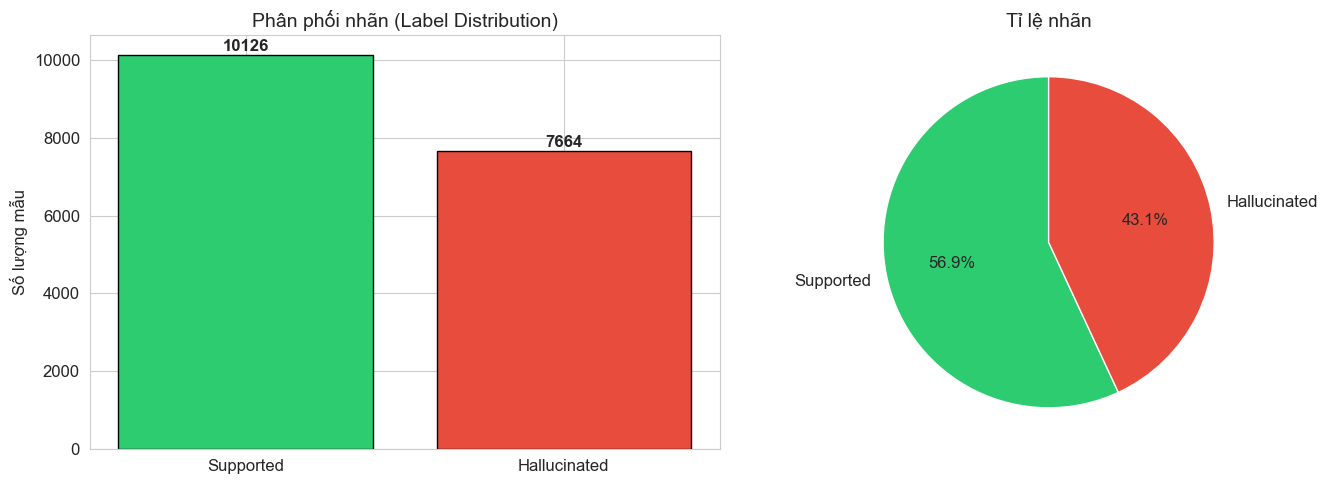

In [6]:
# Trực quan hóa phân phối nhãn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
label_counts = df['label_name'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(label_counts.index, label_counts.values,
            color=colors, edgecolor='black')
axes[0].set_title('Phân phối nhãn (Label Distribution)', fontsize=14)
axes[0].set_ylabel('Số lượng mẫu')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center',
                 fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Tỉ lệ nhãn', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Thống kê mô tả cơ bản
print("=" * 60)
print("THỐNG KÊ MÔ TẢ CƠ BẢN")
print("=" * 60)
print(f"Tổng số mẫu: {len(df)}")
print(f"Số mẫu Supported: {(df['label'] == 0).sum()}")
print(f"Số mẫu Hallucinated: {(df['label'] == 1).sum()}")
print(
    f"Số task_type: {df['task_type'].nunique()} - {df['task_type'].unique().tolist()}")
print(f"Số model: {df['model'].nunique()} - {df['model'].unique().tolist()}")
print(f"\nThống kê độ dài text (ký tự):")
df['text_len_char'] = df['text'].str.len()
print(df['text_len_char'].describe().round(2))

THỐNG KÊ MÔ TẢ CƠ BẢN
Tổng số mẫu: 17790
Số mẫu Supported: 10126
Số mẫu Hallucinated: 7664
Số task_type: 3 - ['Summary', 'Data2txt', 'QA']
Số model: 6 - ['gpt-4-0613', 'gpt-3.5-turbo-0613', 'mistral-7B-instruct', 'llama-2-7b-chat', 'llama-2-13b-chat', 'llama-2-70b-chat']

Thống kê độ dài text (ký tự):
count    17790.00
mean       797.68
std        352.91
min          7.00
25%        553.00
50%        758.50
75%        987.00
max       4007.00
Name: text_len_char, dtype: float64


---
## 2. PHÂN TÍCH THỐNG KÊ VĂN BẢN (Text EDA) [Bắt buộc]

### 2.1. Phân phối độ dài và Mann-Whitney U test

**Lý thuyết:** Phân tích phân phối độ dài văn bản giúp hiểu đặc tính dữ liệu. Mann-Whitney U test là kiểm định phi tham số so sánh hai phân phối độc lập, phù hợp khi dữ liệu không tuân theo phân phối chuẩn. Giả thuyết:
- H0: Phân phối độ dài của hai nhóm là giống nhau
- H1: Phân phối độ dài của hai nhóm là khác nhau

In [8]:
# Tính độ dài theo số từ
df['text_len_words'] = df['text'].apply(lambda x: len(x.split()))
# Tính độ dài theo số câu
df['text_len_sents'] = df['text'].apply(lambda x: len(sent_tokenize(x)))

# Tách theo nhãn
supported_lens = df[df['label'] == 0]['text_len_words']
hallucinated_lens = df[df['label'] == 1]['text_len_words']

print("Thống kê độ dài (số từ) theo nhãn:")
print(
    f"\nSupported:    mean={supported_lens.mean():.1f}, median={supported_lens.median():.1f}, std={supported_lens.std():.1f}")
print(
    f"Hallucinated: mean={hallucinated_lens.mean():.1f}, median={hallucinated_lens.median():.1f}, std={hallucinated_lens.std():.1f}")

Thống kê độ dài (số từ) theo nhãn:

Supported:    mean=118.8, median=111.0, std=56.6
Hallucinated: mean=146.2, median=138.0, std=53.9


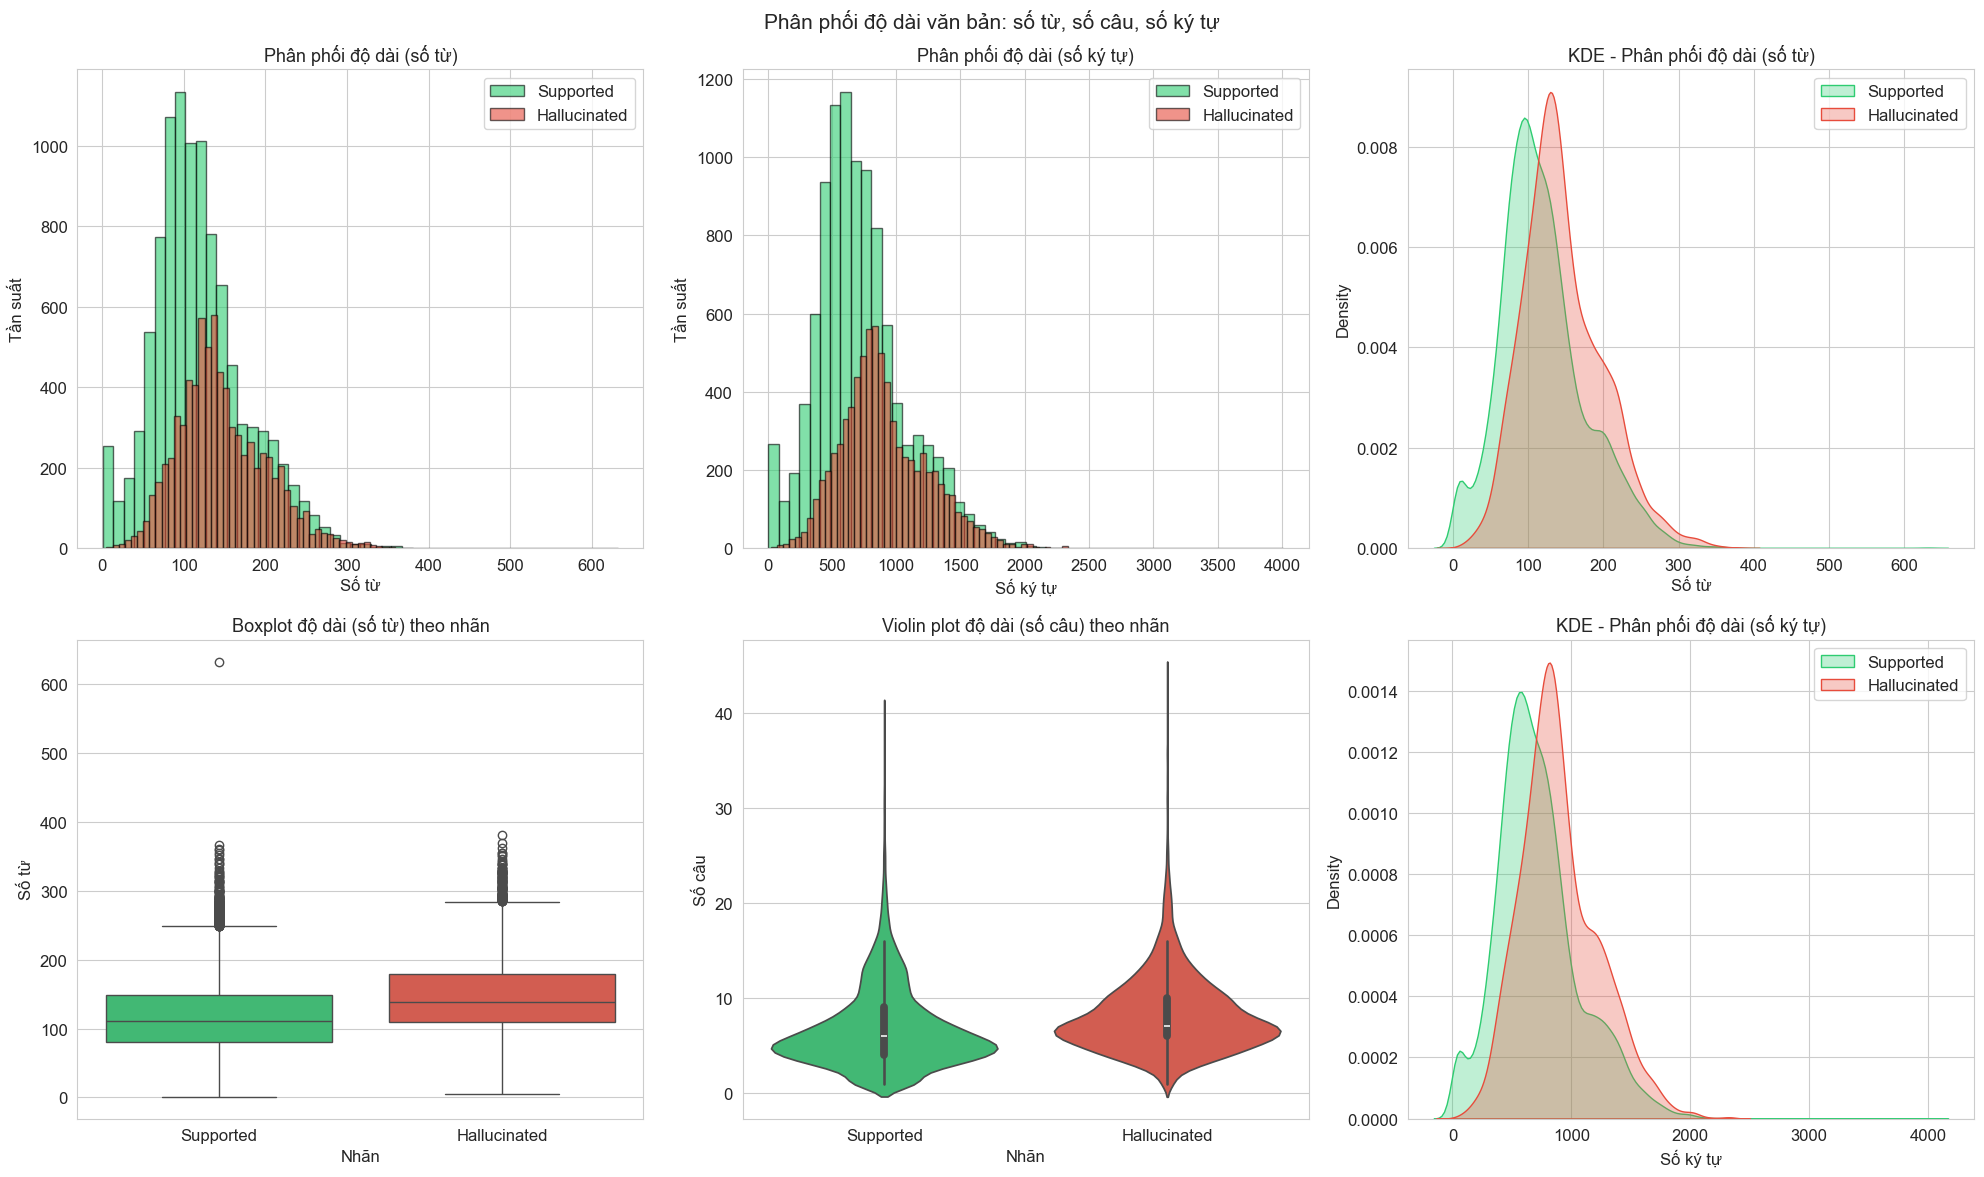

In [9]:
# Trực quan hóa phân phối độ dài (số từ, số câu, số ký tự)
supported_chars_plot = df[df['label'] == 0]['text_len_char']
hallucinated_chars_plot = df[df['label'] == 1]['text_len_char']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# [0,0] Histogram - Số từ
axes[0, 0].hist(supported_lens, bins=50, alpha=0.6,
                label='Supported', color='#2ecc71', edgecolor='black')
axes[0, 0].hist(hallucinated_lens, bins=50, alpha=0.6,
                label='Hallucinated', color='#e74c3c', edgecolor='black')
axes[0, 0].set_title('Phân phối độ dài (số từ)', fontsize=13)
axes[0, 0].set_xlabel('Số từ')
axes[0, 0].set_ylabel('Tần suất')
axes[0, 0].legend()

# [0,1] Histogram - Số ký tự
axes[0, 1].hist(supported_chars_plot, bins=50, alpha=0.6,
                label='Supported', color='#2ecc71', edgecolor='black')
axes[0, 1].hist(hallucinated_chars_plot, bins=50, alpha=0.6,
                label='Hallucinated', color='#e74c3c', edgecolor='black')
axes[0, 1].set_title('Phân phối độ dài (số ký tự)', fontsize=13)
axes[0, 1].set_xlabel('Số ký tự')
axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].legend()

# [0,2] KDE - Số từ
sns.kdeplot(supported_lens,
            ax=axes[0, 2], label='Supported', color='#2ecc71', fill=True, alpha=0.3)
sns.kdeplot(hallucinated_lens,
            ax=axes[0, 2], label='Hallucinated', color='#e74c3c', fill=True, alpha=0.3)
axes[0, 2].set_title('KDE - Phân phối độ dài (số từ)', fontsize=13)
axes[0, 2].set_xlabel('Số từ')
axes[0, 2].legend()

# [1,0] Boxplot - Số từ
sns.boxplot(data=df, x='label_name', y='text_len_words',
            palette=colors, ax=axes[1, 0])
axes[1, 0].set_title('Boxplot độ dài (số từ) theo nhãn', fontsize=13)
axes[1, 0].set_xlabel('Nhãn')
axes[1, 0].set_ylabel('Số từ')

# [1,1] Violin - Số câu
sns.violinplot(data=df, x='label_name', y='text_len_sents',
               palette=colors, ax=axes[1, 1])
axes[1, 1].set_title('Violin plot độ dài (số câu) theo nhãn', fontsize=13)
axes[1, 1].set_xlabel('Nhãn')
axes[1, 1].set_ylabel('Số câu')

# [1,2] KDE - Số ký tự
sns.kdeplot(supported_chars_plot,
            ax=axes[1, 2], label='Supported', color='#2ecc71', fill=True, alpha=0.3)
sns.kdeplot(hallucinated_chars_plot,
            ax=axes[1, 2], label='Hallucinated', color='#e74c3c', fill=True, alpha=0.3)
axes[1, 2].set_title('KDE - Phân phối độ dài (số ký tự)', fontsize=13)
axes[1, 2].set_xlabel('Số ký tự')
axes[1, 2].legend()

plt.suptitle("Phân phối độ dài văn bản: số từ, số câu, số ký tự", fontsize=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'text_length_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Mann-Whitney U Test
stat_words, p_words = mannwhitneyu(
    supported_lens, hallucinated_lens, alternative='two-sided')

supported_chars = df[df['label'] == 0]['text_len_char']
hallucinated_chars = df[df['label'] == 1]['text_len_char']
stat_chars, p_chars = mannwhitneyu(
    supported_chars, hallucinated_chars, alternative='two-sided')

supported_sents = df[df['label'] == 0]['text_len_sents']
hallucinated_sents = df[df['label'] == 1]['text_len_sents']
stat_sents, p_sents = mannwhitneyu(
    supported_sents, hallucinated_sents, alternative='two-sided')

alpha = 0.05

# Tính effect size r = Z / sqrt(N) cho Mann-Whitney
# Z xấp xỉ từ U: Z = (U - mu_U) / sigma_U  (normal approx)
n1_words = len(supported_lens)
n2_words = len(hallucinated_lens)


def mw_effect_size_r(U, n1, n2):
    """Effect size r cho Mann-Whitney U: r = Z / sqrt(N)."""
    mu_U = n1 * n2 / 2
    sig_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    Z = (U - mu_U) / sig_U
    r = abs(Z) / np.sqrt(n1 + n2)
    return Z, r


def interpret_r(r):
    if r < 0.1:
        return "rất nhỏ"
    if r < 0.3:
        return "nhỏ"
    if r < 0.5:
        return "trung bình"
    return "lớn"


z_words, r_words = mw_effect_size_r(stat_words, n1_words, n2_words)
z_chars, r_chars = mw_effect_size_r(
    stat_chars, len(supported_chars), len(hallucinated_chars))
z_sents, r_sents = mw_effect_size_r(
    stat_sents, len(supported_sents), len(hallucinated_sents))

print("=" * 80)
print("MANN-WHITNEY U TEST + EFFECT SIZE r: So sánh phân phối độ dài giữa 2 nhãn")
print("=" * 80)
print(f"\n{'Biến':<15} {'U-stat':>12} {'Z':>8} {'p-value':>12} {'r (effect)':>12} {'Diễn giải'}")
print("-" * 80)
for label, U, Z, p, r in [
    ('Số từ',   stat_words, z_words, p_words, r_words),
    ('Số ký tự', stat_chars, z_chars, p_chars, r_chars),
    ('Số câu',  stat_sents, z_sents, p_sents, r_sents),
]:
    sig = "✓ sig" if p < alpha else "✗ ns"
    print(f"  {label:<13} {U:>12.0f} {Z:>8.3f} {p:>12.2e} {r:>12.4f}  {interpret_r(r)} – {sig}")
print("-" * 80)
print("Effect size r: <0.1 rất nhỏ | 0.1–0.3 nhỏ | 0.3–0.5 trung bình | >0.5 lớn")

MANN-WHITNEY U TEST + EFFECT SIZE r: So sánh phân phối độ dài giữa 2 nhãn

Biến                  U-stat        Z      p-value   r (effect) Diễn giải
--------------------------------------------------------------------------------
  Số từ             27173236  -34.285    1.27e-257       0.2571  nhỏ – ✓ sig
  Số ký tự          26246386  -37.018    5.91e-300       0.2775  nhỏ – ✓ sig
  Số câu            28735755  -29.679    3.40e-195       0.2225  nhỏ – ✓ sig
--------------------------------------------------------------------------------
Effect size r: <0.1 rất nhỏ | 0.1–0.3 nhỏ | 0.3–0.5 trung bình | >0.5 lớn


**Phân tích:**
- Mann-Whitney U test + **effect size r** cho bức tranh đầy đủ: p-value nhỏ KHÔNG đồng nghĩa với sự khác biệt LỚN.
- r < 0.1: dù có ý nghĩa thống kê (do n lớn), sự khác biệt thực tế rất nhỏ → không nên dùng độ dài làm đặc trưng chính.
- r ≥ 0.3: khác biệt trung bình → độ dài có thể là đặc trưng phụ trợ hữu ích.
- Kết quả này phù hợp với trực giác: văn bản chứa ảo giác có thể dài hơn hoặc ngắn hơn do mô hình sinh ra thêm thông tin bịa đặt.

---

### 2.2. Word Cloud, Top-50 từ phổ biến, TTR (Type-Token Ratio)

**Lý thuyết:**
- **Word Cloud**: Trực quan hóa tần suất từ, từ xuất hiện nhiều có kích thước lớn hơn.
- **Top-50**: Phân tích từ vựng phổ biến nhất trong mỗi nhóm.
- **TTR (Type-Token Ratio)**: Tỉ lệ giữa số từ duy nhất (types) và tổng số từ (tokens). TTR cao → từ vựng phong phú, đa dạng.

In [11]:
# Tokenize tất cả văn bản
all_tokens = []
supported_tokens = []
hallucinated_tokens = []

for _, row in df.iterrows():
    tokens = word_tokenize(row['text'].lower())
    tokens = [t for t in tokens if t.isalpha()]  # Chỉ giữ từ alphabet
    all_tokens.extend(tokens)
    if row['label'] == 0:
        supported_tokens.extend(tokens)
    else:
        hallucinated_tokens.extend(tokens)

print(f"Tổng số tokens (all):          {len(all_tokens):,}")
print(f"Tổng số tokens (Supported):    {len(supported_tokens):,}")
print(f"Tổng số tokens (Hallucinated): {len(hallucinated_tokens):,}")
print(f"\nSố types (unique words) (all):          {len(set(all_tokens)):,}")
print(
    f"Số types (unique words) (Supported):    {len(set(supported_tokens)):,}")
print(
    f"Số types (unique words) (Hallucinated): {len(set(hallucinated_tokens)):,}")

Tổng số tokens (all):          2,242,474
Tổng số tokens (Supported):    1,160,153
Tổng số tokens (Hallucinated): 1,082,321

Số types (unique words) (all):          28,013


Số types (unique words) (Supported):    24,958
Số types (unique words) (Hallucinated): 21,828


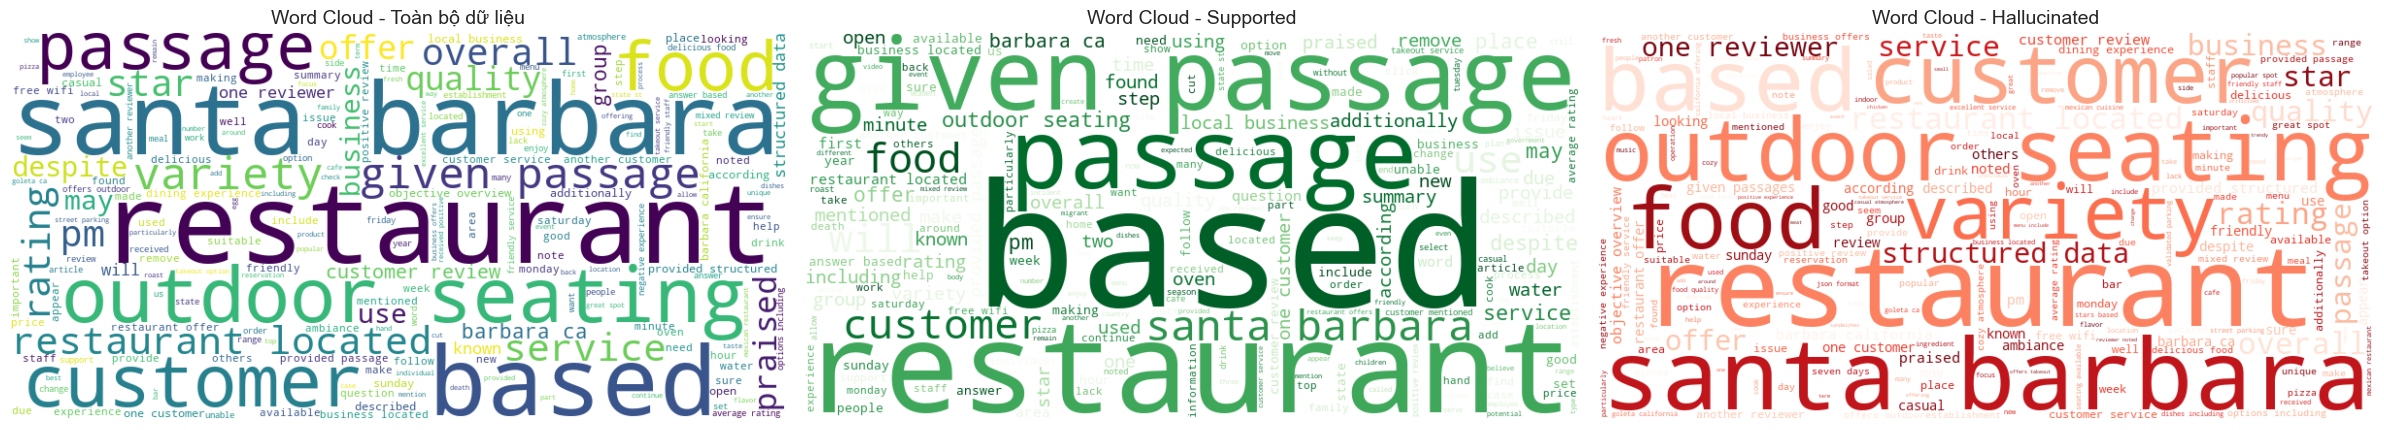

In [12]:
# Word Cloud
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# All
wc_all = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap='viridis').generate(' '.join(all_tokens))
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('Word Cloud - Toàn bộ dữ liệu', fontsize=14)
axes[0].axis('off')

# Supported
wc_sup = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap='Greens').generate(' '.join(supported_tokens))
axes[1].imshow(wc_sup, interpolation='bilinear')
axes[1].set_title('Word Cloud - Supported', fontsize=14)
axes[1].axis('off')

# Hallucinated
wc_hal = WordCloud(width=800, height=400, background_color='white',
                   max_words=200, colormap='Reds').generate(' '.join(hallucinated_tokens))
axes[2].imshow(wc_hal, interpolation='bilinear')
axes[2].set_title('Word Cloud - Hallucinated', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Top-50 từ phổ biến
all_freq = Counter(all_tokens)
sup_freq = Counter(supported_tokens)
hal_freq = Counter(hallucinated_tokens)

top50_all = all_freq.most_common(50)
top50_sup = sup_freq.most_common(50)
top50_hal = hal_freq.most_common(50)

# Hiển thị top-50 dưới dạng bảng
top50_df = pd.DataFrame({
    'Rank': range(1, 51),
    'All_Word': [w for w, _ in top50_all],
    'All_Freq': [f for _, f in top50_all],
    'Supported_Word': [w for w, _ in top50_sup],
    'Supported_Freq': [f for _, f in top50_sup],
    'Hallucinated_Word': [w for w, _ in top50_hal],
    'Hallucinated_Freq': [f for _, f in top50_hal]
})
print("TOP-50 TỪ PHỔ BIẾN NHẤT:")
top50_df

TOP-50 TỪ PHỔ BIẾN NHẤT:


,Rank,All_Word,All_Freq,Supported_Word,Supported_Freq,Hallucinated_Word,Hallucinated_Freq
0,1,the,154735,the,83407,the,71328
1,2,and,91797,and,43061,and,48736
2,3,a,68935,to,33798,a,35736
3,4,to,58341,a,33199,of,25432
4,5,of,52045,of,26613,to,24543
5,6,in,37223,in,19977,is,18629
6,7,is,35133,is,16504,in,17246
7,8,for,30388,for,14596,for,15792
8,9,with,24491,on,12983,with,13298
9,10,on,24062,with,11193,on,11079


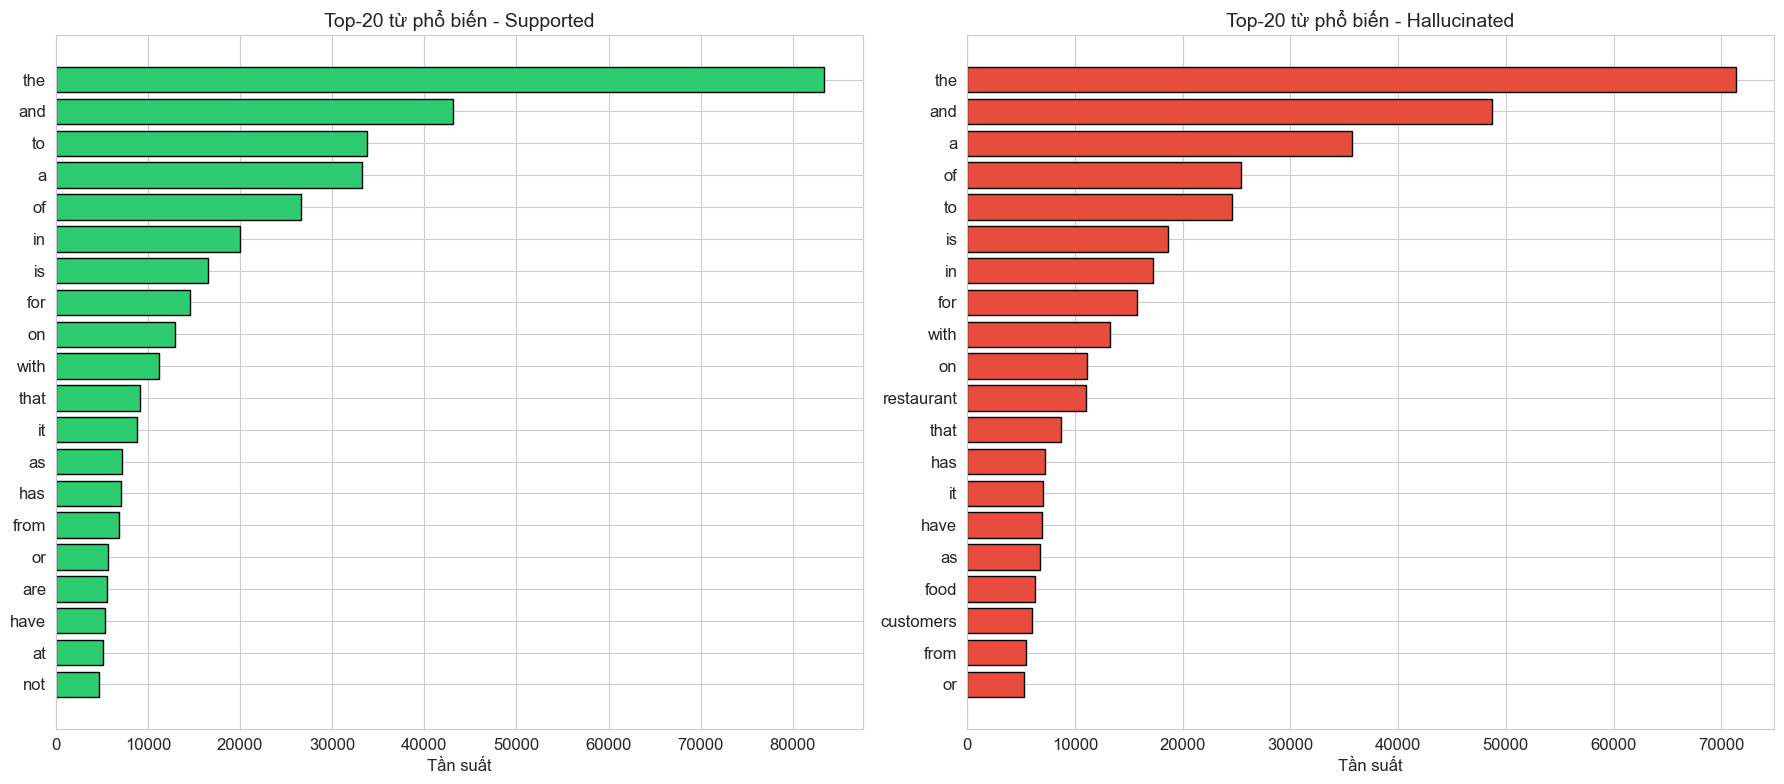

In [14]:
# Trực quan hóa Top-20 từ phổ biến
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top20_sup = sup_freq.most_common(20)
top20_hal = hal_freq.most_common(20)

axes[0].barh([w for w, _ in top20_sup][::-1], [f for _, f in top20_sup]
             [::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top-20 từ phổ biến - Supported', fontsize=14)
axes[0].set_xlabel('Tần suất')

axes[1].barh([w for w, _ in top20_hal][::-1], [f for _, f in top20_hal]
             [::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top-20 từ phổ biến - Hallucinated', fontsize=14)
axes[1].set_xlabel('Tần suất')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top20_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# TTR (Type-Token Ratio)
ttr_all = len(set(all_tokens)) / len(all_tokens)
ttr_sup = len(set(supported_tokens)) / len(supported_tokens)
ttr_hal = len(set(hallucinated_tokens)) / len(hallucinated_tokens)

# TTR theo từng mẫu
df['ttr'] = df['text'].apply(lambda x: len(
    set(x.lower().split())) / max(len(x.lower().split()), 1))

print("=" * 60)
print("TYPE-TOKEN RATIO (TTR)")
print("=" * 60)
print(f"TTR toàn bộ corpus:  {ttr_all:.4f}")
print(f"TTR Supported:       {ttr_sup:.4f}")
print(f"TTR Hallucinated:    {ttr_hal:.4f}")
print(f"\nTTR trung bình theo mẫu:")
print(
    f"  Supported:    {df[df['label'] == 0]['ttr'].mean():.4f} ± {df[df['label'] == 0]['ttr'].std():.4f}")
print(
    f"  Hallucinated: {df[df['label'] == 1]['ttr'].mean():.4f} ± {df[df['label'] == 1]['ttr'].std():.4f}")

# Mann-Whitney U test cho TTR
stat_ttr, p_ttr = mannwhitneyu(
    df[df['label'] == 0]['ttr'], df[df['label'] == 1]['ttr'], alternative='two-sided')
print(f"\nMann-Whitney U test cho TTR: U={stat_ttr:.2f}, p={p_ttr:.2e}")
print(
    f"  => TTR {'KHÁC BIỆT' if p_ttr < 0.05 else 'KHÔNG khác biệt'} có ý nghĩa thống kê giữa 2 nhóm")

TYPE-TOKEN RATIO (TTR)
TTR toàn bộ corpus:  0.0125
TTR Supported:       0.0215
TTR Hallucinated:    0.0202

TTR trung bình theo mẫu:
  Supported:    0.7130 ± 0.1049
  Hallucinated: 0.6881 ± 0.0834

Mann-Whitney U test cho TTR: U=44307909.50, p=3.11e-59
  => TTR KHÁC BIỆT có ý nghĩa thống kê giữa 2 nhóm


**Phân tích:**
- Word Cloud cho thấy tổng quan các từ phổ biến nhất. Cả hai nhóm đều chia sẻ nhiều từ chung (stop words).
- Top-50 từ phổ biến giúp so sánh chi tiết sự khác biệt từ vựng giữa hai nhóm.
- TTR cho thấy mức độ đa dạng từ vựng. TTR thấp hơn ở cấp corpus (do lượng token lớn) nhưng TTR theo mẫu phản ánh tốt hơn sự đa dạng.

---

### 2.3. Phân tích Định luật Zipf

**Lý thuyết:** Định luật Zipf phát biểu rằng trong một corpus ngôn ngữ tự nhiên, tần suất của một từ tỉ lệ nghịch với hạng (rank) của nó. Cụ thể: f(r) ∝ 1/r^α, hay log(f) = -α·log(r) + C. Khi vẽ trên thang log-log, ta sẽ thấy đường thẳng nếu dữ liệu tuân theo định luật Zipf.

In [16]:
# Phân tích Zipf's Law
freq_sorted = sorted(all_freq.values(), reverse=True)
ranks = np.arange(1, len(freq_sorted) + 1)
frequencies = np.array(freq_sorted)

# Fit linear regression trên log-log
log_ranks = np.log10(ranks)
log_freqs = np.log10(frequencies)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    log_ranks, log_freqs)

print("=" * 60)
print("PHÂN TÍCH ĐỊNH LUẬT ZIPF")
print("=" * 60)
print(f"Hệ số Zipf (slope):     α = {abs(slope):.4f}")
print(f"Intercept:               C = {intercept:.4f}")
print(f"R² (coefficient):        R² = {r_value**2:.4f}")
print(f"p-value:                 p = {p_value:.2e}")
print(f"\nĐịnh luật Zipf lý tưởng: α ≈ 1.0")
print(
    f"Corpus này: α = {abs(slope):.4f} => {'Tuân theo Zipf tốt' if 0.7 < abs(slope) < 1.3 else 'Lệch so với Zipf'}")
# statsmodels OLS (Requirement §3.1)
X_zipf = sm.add_constant(log_ranks)
ols_zipf = sm.OLS(log_freqs, X_zipf).fit()
print(f"statsmodels OLS α: {ols_zipf.params[1]:.4f} | scipy: {slope:.4f}")

PHÂN TÍCH ĐỊNH LUẬT ZIPF
Hệ số Zipf (slope):     α = 1.6306
Intercept:               C = 7.4432
R² (coefficient):        R² = 0.9357
p-value:                 p = 0.00e+00

Định luật Zipf lý tưởng: α ≈ 1.0
Corpus này: α = 1.6306 => Lệch so với Zipf
statsmodels OLS α: -1.6306 | scipy: -1.6306


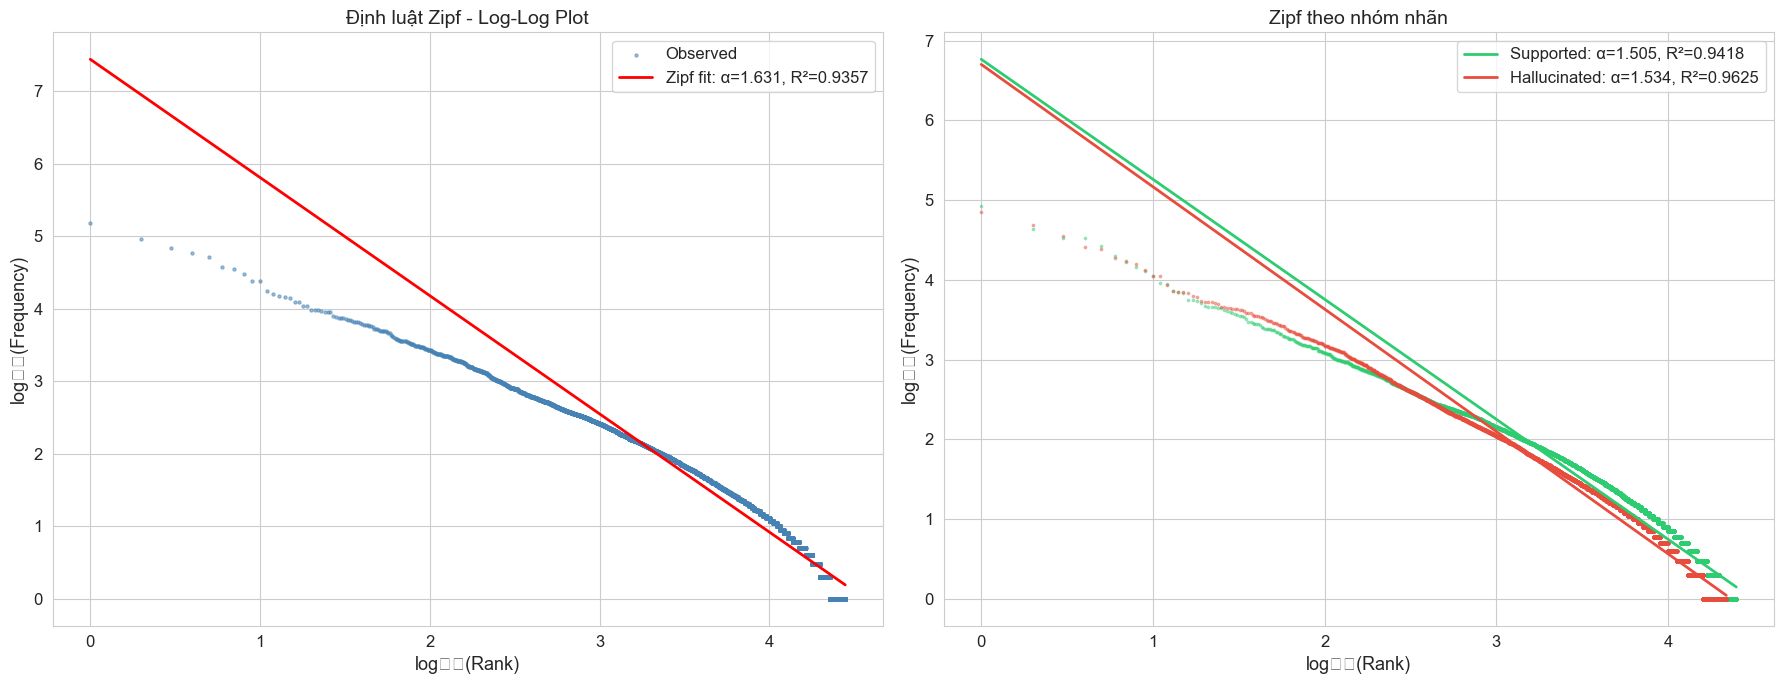

Zipf α: 1.631 (toàn corpus) | 1.505 (Supported) | 1.534 (Hallucinated)


In [17]:
# Vẽ đồ thị Zipf log-log
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Log-log plot
axes[0].scatter(log_ranks, log_freqs, s=5, alpha=0.5,
                color='steelblue', label='Observed')
fitted_line = slope * log_ranks + intercept
axes[0].plot(log_ranks, fitted_line, 'r-', linewidth=2,
             label=f'Zipf fit: α={abs(slope):.3f}, R²={r_value**2:.4f}')
axes[0].set_xlabel('log₁₀(Rank)', fontsize=13)
axes[0].set_ylabel('log₁₀(Frequency)', fontsize=13)
axes[0].set_title("Định luật Zipf - Log-Log Plot", fontsize=14)
axes[0].legend(fontsize=12)

# Zipf cho từng nhóm
_zipf_slopes = {}
for label_name, freq_counter, color in [('Supported', sup_freq, '#2ecc71'), ('Hallucinated', hal_freq, '#e74c3c')]:
    freq_s = sorted(freq_counter.values(), reverse=True)
    r = np.arange(1, len(freq_s) + 1)
    s, i, rv, _, _ = stats.linregress(np.log10(r), np.log10(freq_s))
    _zipf_slopes[label_name] = s
    axes[1].scatter(np.log10(r), np.log10(freq_s), s=3, alpha=0.4, color=color)
    axes[1].plot(np.log10(r), s * np.log10(r) + i, color=color, linewidth=2,
                 label=f'{label_name}: α={abs(s):.3f}, R²={rv**2:.4f}')

axes[1].set_xlabel('log₁₀(Rank)', fontsize=13)
axes[1].set_ylabel('log₁₀(Frequency)', fontsize=13)
axes[1].set_title('Zipf theo nhóm nhãn', fontsize=14)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'zipf_law.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Zipf \u03b1: {abs(slope):.3f} (to\u00e0n corpus) | "
      f"{abs(_zipf_slopes['Supported']):.3f} (Supported) | "
      f"{abs(_zipf_slopes['Hallucinated']):.3f} (Hallucinated)")

**Phân tích:**
- Đồ thị log-log cho thấy quan hệ gần tuyến tính giữa rank và frequency (R² cao), nên xu hướng Zipf vẫn hiện diện rõ.
- Tuy nhiên hệ số \(\alpha\) ước lượng (in ở print cell phía trên, thường xa 1.0), cho thấy corpus **lệch** so với Zipf lý tưởng và thiên mạnh về một số từ rất phổ biến.
- Hai nhóm nhãn đều giữ xu hướng Zipf tương tự nhau, nhưng mức lệch khỏi \(\alpha\approx1\) cần được nêu rõ khi diễn giải.

---
## 3. CÁC KỸ THUẬT TIỀN XỬ LÝ VÀ PHÂN TÍCH TÁC ĐỘNG

### 3.1. Pipeline Chuẩn hóa Văn bản [Bắt buộc]

**Lý thuyết:** Pipeline chuẩn hóa bao gồm 9 bước tuần tự: (1) lowercase, (2) xóa HTML tags,
(3) xóa URL, (4) xóa email, (5) xóa mention (@user), (6) xóa hashtag (#topic), (7) xóa số,
(8) xóa ký tự đặc biệt, (9) chuẩn hóa khoảng trắng.
Với **mỗi bước**, bảng bên dưới báo cáo tỉ lệ từ vựng thay đổi và tác động đến độ dài văn bản.

In [18]:
# ── Tách từng bước pipeline để đo per-step vocab change (§2.3.3a yêu cầu) ──────
PIPELINE_STEPS = [
    ('lowercase', lambda t: t.lower()),
    ('remove_html', lambda t: re.sub(r'<[^>]+>', '', t)),
    ('remove_url', lambda t: re.sub(r'http\S+|www\S+|https\S+', '', t)),
    ('remove_email', lambda t: re.sub(r'\S+@\S+', '', t)),
    ('remove_mention', lambda t: re.sub(r'@\w+', '', t)),
    ('remove_hashtag', lambda t: re.sub(r'#\w+', '', t)),
    ('remove_number', lambda t: re.sub(r'\d+', '', t)),
    ('remove_punct', lambda t: re.sub(r'[^a-zA-Z\s]', '', t)),
    ('normalize_ws', lambda t: re.sub(r'\s+', ' ', t).strip()),
]


def normalize_text(text):
    """Pipeline chuẩn hóa văn bản — áp dụng tuần tự các bước."""
    for _, fn in PIPELINE_STEPS:
        text = fn(text)
    return text


# Đo per-step vocab change — §2.3.3a yêu cầu "với mỗi bước, báo cáo tỉ lệ từ vựng thay đổi"
print("=" * 80)
print("BẢNG THỐNG KÊ PER-STEP PIPELINE CHUẨN HÓA (§2.3.3a)")
print("=" * 80)

_corpus = df['text'].tolist()
_base_vocab = set(t for doc in _corpus for t in word_tokenize(doc))
_base_len = float(np.mean([len(word_tokenize(doc)) for doc in _corpus]))
_base_chars = float(pd.Series([len(doc) for doc in _corpus]).mean())

_step_rows = [{'Bước': 'Nguyên bản (raw)',
               'Vocab Size': len(_base_vocab),
               'Δ Vocab (%)': 0.0,
               'Mean Tokens/Doc': round(_base_len, 1),
               'Δ Length (%)': 0.0,
               'Mean Chars/Doc': round(_base_chars, 1)}]

_current_corpus = _corpus.copy()
_prev_vocab = len(_base_vocab)
_prev_len = _base_len
for step_name, step_fn in PIPELINE_STEPS:
    _current_corpus = [step_fn(doc) for doc in _current_corpus]
    _tok_now = [word_tokenize(doc) for doc in _current_corpus]
    _vocab_now = set(t for toks in _tok_now for t in toks)
    _len_now = float(np.mean([len(toks) for toks in _tok_now]))
    _chars_now = float(pd.Series([len(doc) for doc in _current_corpus]).mean())
    _step_rows.append({
        'Bước': step_name,
        'Vocab Size': len(_vocab_now),
        'Δ Vocab (%)': round((len(_vocab_now) - _prev_vocab) / max(_prev_vocab, 1) * 100, 2),
        'Mean Tokens/Doc': round(_len_now, 1),
        'Δ Length (%)': round((_len_now - _prev_len) / max(_prev_len, 1e-9) * 100, 2),
        'Mean Chars/Doc': round(_chars_now, 1),
    })
    _prev_vocab = len(_vocab_now)
    _prev_len = _len_now

PIPELINE_STEP_TABLE = pd.DataFrame(_step_rows)
print(PIPELINE_STEP_TABLE.to_string(index=False))
print(f"\nTổng giảm vocab: {len(_base_vocab):,} → {_prev_vocab:,} "
      f"({(_prev_vocab - len(_base_vocab)) / max(len(_base_vocab), 1)*100:.1f}%)")
print(f"Tổng giảm độ dài: {_base_len:.1f} → {_prev_len:.1f} tokens/doc "
      f"({(_prev_len - _base_len) / max(_base_len, 1e-9)*100:.1f}%)")

# Tỉ lệ giảm vocab qua toàn bộ pipeline (dùng cho ablation summary)
VOCAB_REDUCTION_RATIO = (len(_base_vocab) - _prev_vocab) / \
    max(len(_base_vocab), 1)

# Áp dụng pipeline đầy đủ cho toàn bộ dataframe
df['text_normalized'] = df['text'].apply(normalize_text)

print(f"\nVí dụ trước và sau chuẩn hóa:")
for i in range(3):
    print(f"\n--- Mẫu {i+1} ---")
    print(f"TRƯỚC: {df['text'].iloc[i][:200]}...")
    print(f"SAU:   {df['text_normalized'].iloc[i][:200]}...")

BẢNG THỐNG KÊ PER-STEP PIPELINE CHUẨN HÓA (§2.3.3a)


            Bước  Vocab Size  Δ Vocab (%)  Mean Tokens/Doc  Δ Length (%)  Mean Chars/Doc
Nguyên bản (raw)       40613         0.00            150.0          0.00           797.7
       lowercase       34560       -14.90            149.2         -0.49           797.7
     remove_html       34554        -0.02            149.2         -0.00           797.7
      remove_url       34535        -0.05            149.2         -0.00           797.6
    remove_email       34534        -0.00            149.2         -0.00           797.6
  remove_mention       34532        -0.01            149.2         -0.00           797.6
  remove_hashtag       34510        -0.06            149.2         -0.01           797.5
   remove_number       31558        -8.55            147.8         -0.95           790.9
    remove_punct       31946         1.23            127.4        -13.82           769.1
    normalize_ws       31946         0.00            127.4          0.00           764.7

Tổng giảm vocab: 40,


Ví dụ trước và sau chuẩn hóa:

--- Mẫu 1 ---
TRƯỚC: The Anne Frank House has revealed that Anne Frank and her older sister, Margot, likely died at least a month earlier than previously believed. The sisters, who were imprisoned in Nazi concentration ca...
SAU:   the anne frank house has revealed that anne frank and her older sister margot likely died at least a month earlier than previously believed the sisters who were imprisoned in nazi concentration camps ...

--- Mẫu 2 ---
TRƯỚC: New research released by the Anne Frank House reveals that Anne Frank and her older sister, Margot, died at least a month earlier than previously believed. The research involved re-examining archives ...
SAU:   new research released by the anne frank house reveals that anne frank and her older sister margot died at least a month earlier than previously believed the research involved reexamining archives and ...

--- Mẫu 3 ---
TRƯỚC: New research conducted by the Anne Frank House has revealed that Anne Fra

**Phân tích:**
- Bảng `PIPELINE_STEP_TABLE` in ra vocab size và Δ% sau **mỗi bước riêng biệt**.
- Bước tạo giảm vocab nhiều nhất thường là `remove_punct` và `lowercase` (gộp case variants).
- `remove_html`, `remove_url`, `remove_mention`, `remove_hashtag` ảnh hưởng phụ thuộc corpus —
  với RAGTruth (văn bản phân tích AI), HTML và URL thường ít → giảm chủ yếu ở `remove_number` và `remove_punct`.
- Độ dài trung bình (tokens/doc) giảm dần qua pipeline — phản ánh loại bỏ noise tokens.

---

### 3.2. Tokenization [Bắt buộc]

**Lý thuyết:** So sánh 4 phương pháp tokenization:
- **Word-level**: Tách theo khoảng trắng và dấu câu. Đơn giản nhưng OOV cao.
- **Sentence-level**: Tách thành câu. Giữ ngữ cảnh nhưng độ phân giải thấp.
- **Character-level**: Tách từng ký tự. Không OOV nhưng mất ngữ nghĩa, chuỗi rất dài.
- **Subword (BPE)**: Tách thành subword units. Cân bằng giữa OOV và kích thước từ vựng.

In [19]:
# Lấy mẫu để phân tích (dùng text đã chuẩn hóa)
sample_texts = df['text_normalized'].tolist()

# 1. Word-level tokenization (NLTK)
word_tokenized = [word_tokenize(t) for t in sample_texts]
word_vocab = set(tok for tokens in word_tokenized for tok in tokens)
word_lengths = [len(t) for t in word_tokenized]

# 1b. Word-level tokenization (spaCy)
spacy_tokenized = [[token.text for token in doc]
                   for doc in nlp.pipe(sample_texts, batch_size=256)]
spacy_vocab = set(tok for tokens in spacy_tokenized for tok in tokens)
spacy_lengths = [len(t) for t in spacy_tokenized]

# 2. Sentence-level tokenization (NLTK)
# Dùng text gốc cho sentence
sent_tokenized = [sent_tokenize(t) for t in df['text'].tolist()]
sent_lengths = [len(t) for t in sent_tokenized]

# 3. Character-level tokenization
char_tokenized = [list(t) for t in sample_texts]
char_vocab = set(c for chars in char_tokenized for c in chars)
char_lengths = [len(t) for t in char_tokenized]

# 4. Subword (BPE) tokenization
bpe_tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
bpe_trainer = BpeTrainer(vocab_size=10000, special_tokens=[
                         '[UNK]', '[PAD]', '[CLS]', '[SEP]'])
bpe_tokenizer.pre_tokenizer = Whitespace()

# Train BPE trên corpus
bpe_tokenizer.train_from_iterator(sample_texts, trainer=bpe_trainer)
bpe_tokenized = [bpe_tokenizer.encode(t).tokens for t in sample_texts]
bpe_vocab = set(tok for tokens in bpe_tokenized for tok in tokens)
bpe_lengths = [len(t) for t in bpe_tokenized]

# Tính OOV (Out-of-Vocabulary) - dùng 80% dữ liệu làm vocab, 20% đánh giá OOV
split_idx = int(len(sample_texts) * 0.8)

# Word-level OOV
train_word_vocab = set(
    tok for tokens in word_tokenized[:split_idx] for tok in tokens)
test_word_tokens = [tok for tokens in word_tokenized[split_idx:]
                    for tok in tokens]
word_oov = sum(1 for t in test_word_tokens if t not in train_word_vocab) / \
    max(len(test_word_tokens), 1)

# BPE OOV
train_bpe_vocab = set(
    tok for tokens in bpe_tokenized[:split_idx] for tok in tokens)
test_bpe_tokens = [tok for tokens in bpe_tokenized[split_idx:]
                   for tok in tokens]
bpe_oov = sum(1 for t in test_bpe_tokens if t not in train_bpe_vocab) / \
    max(len(test_bpe_tokens), 1)

# spaCy OOV
train_spacy_vocab = set(tok for tokens in spacy_tokenized[:split_idx] for tok in tokens)
test_spacy_tokens = [tok for tokens in spacy_tokenized[split_idx:] for tok in tokens]
spacy_oov = sum(1 for t in test_spacy_tokens if t not in train_spacy_vocab) / \
    max(len(test_spacy_tokens), 1)

# Tổng hợp kết quả
tokenization_results = pd.DataFrame({
    'Method': ['Word (NLTK)', 'Word (spaCy)', 'Sentence-level', 'Character-level', 'Subword (BPE)'],
    'Vocab Size': [len(word_vocab), len(spacy_vocab), '-', len(char_vocab), len(bpe_vocab)],
    'Avg Token Length': [np.mean(word_lengths), np.mean(spacy_lengths), np.mean(sent_lengths), np.mean(char_lengths), np.mean(bpe_lengths)],
    'Median Token Length': [np.median(word_lengths), np.median(spacy_lengths), np.median(sent_lengths), np.median(char_lengths), np.median(bpe_lengths)],
    'OOV Ratio': [f'{word_oov:.4f}', f'{spacy_oov:.4f}', 'N/A', '0.0000', f'{bpe_oov:.4f}']
})

print("=" * 70)
print("SO SÁNH CÁC PHƯƠNG PHÁP TOKENIZATION")
print("=" * 70)
tokenization_results

SO SÁNH CÁC PHƯƠNG PHÁP TOKENIZATION


,Method,Vocab Size,Avg Token Length,Median Token Length,OOV Ratio
0,Word (NLTK),31946,127.367510,121.0,0.0264
1,Word (spaCy),31914,127.459696,121.0,0.0264
2,Sentence-level,-,7.446824,6.0,N/A
3,Character-level,27,764.745812,726.5,0.0000
4,Subword (BPE),9695,138.451152,130.0,0.0023


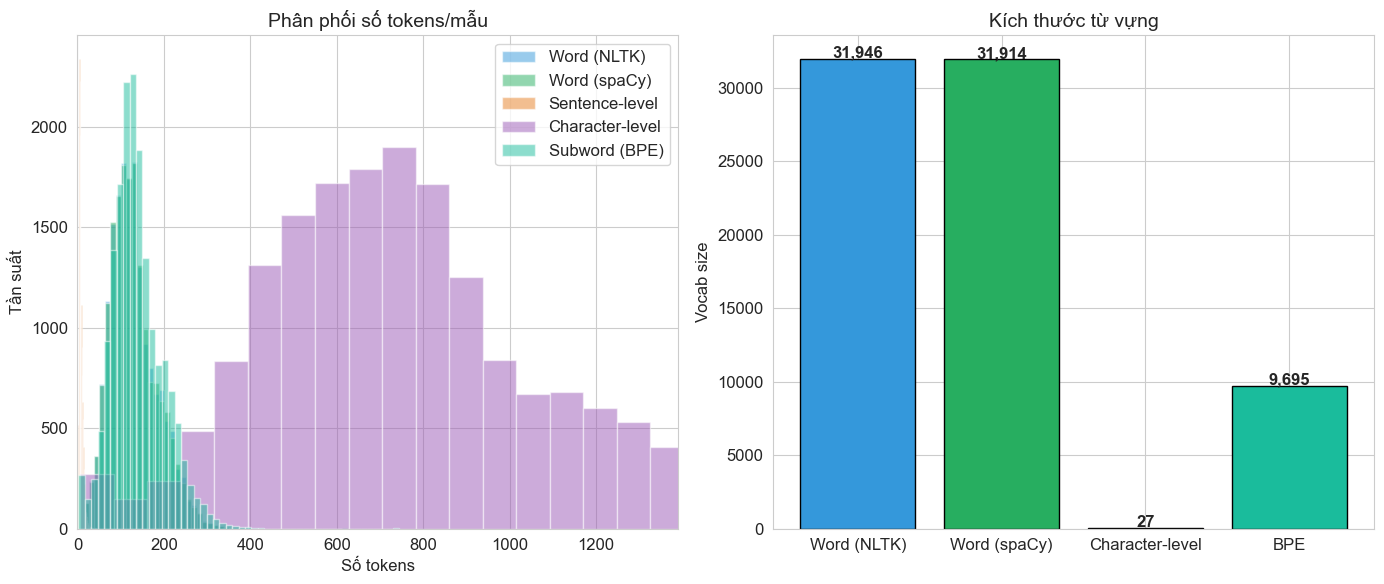

In [20]:
# Trực quan hóa so sánh tokenization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Phân phối độ dài token
methods = ['Word (NLTK)', 'Word (spaCy)', 'Sentence-level', 'Character-level', 'Subword (BPE)']
all_lengths = [word_lengths, spacy_lengths, sent_lengths, char_lengths, bpe_lengths]
colors_tok = ['#3498db', '#27ae60', '#e67e22', '#9b59b6', '#1abc9c']

for i, (m, l, c) in enumerate(zip(methods, all_lengths, colors_tok)):
    axes[0].hist(l, bins=50, alpha=0.5, label=m, color=c)
axes[0].set_title('Phân phối số tokens/mẫu', fontsize=14)
axes[0].set_xlabel('Số tokens')
axes[0].set_ylabel('Tần suất')
axes[0].legend()
axes[0].set_xlim(0, np.percentile(char_lengths, 95))

# Kích thước từ vựng (bar chart)
vocab_sizes = [len(word_vocab), len(spacy_vocab), len(char_vocab), len(bpe_vocab)]
vocab_labels = ['Word (NLTK)', 'Word (spaCy)', 'Character-level', 'BPE']
bars = axes[1].bar(vocab_labels, vocab_sizes, color=[
                   '#3498db', '#27ae60', '#9b59b6', '#1abc9c'], edgecolor='black')
axes[1].set_title('Kích thước từ vựng', fontsize=14)
axes[1].set_ylabel('Vocab size')
for bar, v in zip(bars, vocab_sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() +
                 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tokenization_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Phân tích:**
- **Word-level** có kích thước từ vựng lớn nhất nhưng OOV cao hơn vì gặp từ mới dễ dàng.
- **Character-level** có từ vựng nhỏ nhất (~26 chữ cái + khoảng trắng) nhưng chuỗi token rất dài.
- **BPE** cân bằng tốt nhất: từ vựng vừa phải, OOV thấp, độ dài hợp lý. Ở notebook này BPE được huấn luyện trực tiếp trên corpus (`train_from_iterator`), không dùng tokenizer prebuilt.
- **Sentence-level** phù hợp cho tác vụ cấp câu; OOV kiểu *từ* không định nghĩa trực tiếp → bảng ghi `N/A`.

**Lựa chọn cho pipeline downstream:** BPE đạt OOV thấp nhất nhưng subword units không tương thích với
NLTK stop word list và WordNet lemmatizer (cần whole-word tokens). Do đó **Word-level** được chọn cho các bước 3.3–3.5.

In [21]:
# === QUYẾT ĐỊNH 1: TOKENIZATION ===
CHOSEN_TOKENIZER = 'Word-level'
print(f"[CHỌN] Tokenizer: {CHOSEN_TOKENIZER}")
print(
    f"  Word-level OOV={word_oov:.4f} → được kiểm soát bởi min_df/max_features trong TF-IDF")
print(
    f"  BPE OOV={bpe_oov:.4f} thấp hơn nhưng subwords không tương thích với stop word list + lemmatizer")
print(f"  → Bước 3.3 và 3.4 sẽ dùng df['tokens'] (word-level)")

[CHỌN] Tokenizer: Word-level
  Word-level OOV=0.0264 → được kiểm soát bởi min_df/max_features trong TF-IDF
  BPE OOV=0.0023 thấp hơn nhưng subwords không tương thích với stop word list + lemmatizer
  → Bước 3.3 và 3.4 sẽ dùng df['tokens'] (word-level)


---

### 3.3. Stop Words [Bắt buộc]

**Lý thuyết:** Stop words là các từ xuất hiện rất thường xuyên nhưng mang ít ý nghĩa ngữ nghĩa (the, is, at, which...). Việc loại bỏ stop words giúp:
- Giảm kích thước từ vựng và chiều của ma trận đặc trưng
- Tập trung vào các từ mang ý nghĩa phân biệt

Tuy nhiên, trong một số trường hợp, stop words có thể mang thông tin hữu ích (phong cách viết, ngữ pháp).

In [22]:
# Phân tích Stop Words
stop_words = set(stopwords.words('english'))
print(f"Số lượng stop words trong NLTK English: {len(stop_words)}")
print(f"Một số stop words: {list(stop_words)[:20]}")

# Tokenize và tách stop words vs non-stop words
df['tokens'] = df['text_normalized'].apply(lambda x: word_tokenize(x))
df['tokens_no_stop'] = df['tokens'].apply(
    lambda x: [t for t in x if t not in stop_words])

# So sánh kích thước từ vựng
vocab_with_stop = set(tok for tokens in df['tokens'] for tok in tokens)
vocab_no_stop = set(tok for tokens in df['tokens_no_stop'] for tok in tokens)

print(f"\n{'='*60}")
print("SO SÁNH TRƯỚC VÀ SAU KHI XÓA STOP WORDS")
print(f"{'='*60}")
print(f"Kích thước từ vựng CÓ stop words:    {len(vocab_with_stop):,}")
print(f"Kích thước từ vựng KHÔNG stop words:  {len(vocab_no_stop):,}")
print(
    f"Tỉ lệ giảm từ vựng: {(1 - len(vocab_no_stop) / len(vocab_with_stop)) * 100:.2f}%")

total_with = sum(len(t) for t in df['tokens'])
total_without = sum(len(t) for t in df['tokens_no_stop'])
print(f"\nTổng tokens CÓ stop words:    {total_with:,}")
print(f"Tổng tokens KHÔNG stop words:  {total_without:,}")
print(f"Tỉ lệ tokens bị loại: {(1 - total_without / total_with) * 100:.2f}%")

Số lượng stop words trong NLTK English: 198
Một số stop words: ["she's", "hasn't", "he's", 'mustn', 'himself', "you'll", 'to', 'only', 'itself', "you'd", 'their', 'over', 'wasn', 's', 'what', "mustn't", 'all', 'ain', 'isn', 'but']



SO SÁNH TRƯỚC VÀ SAU KHI XÓA STOP WORDS
Kích thước từ vựng CÓ stop words:    31,946
Kích thước từ vựng KHÔNG stop words:  31,816
Tỉ lệ giảm từ vựng: 0.41%

Tổng tokens CÓ stop words:    2,265,868
Tổng tokens KHÔNG stop words:  1,334,932
Tỉ lệ tokens bị loại: 41.09%


In [23]:
# Mutual Information: đo mức độ thông tin của từng từ với nhãn
# Tạo BoW cho cả 2 trường hợp
cv_with_stop = CountVectorizer(max_features=5000)
X_with_stop = cv_with_stop.fit_transform(df['text_normalized'])

cv_no_stop = CountVectorizer(max_features=5000, stop_words='english')
X_no_stop = cv_no_stop.fit_transform(df['text_normalized'])

y = df['label'].values

# Tính MI cho từng feature
mi_with = mutual_info_classif(
    X_with_stop, y, discrete_features=True, random_state=SEED)
mi_no = mutual_info_classif(
    X_no_stop, y, discrete_features=True, random_state=SEED)

MI_MEAN_WITH_STOP = float(np.mean(mi_with))
MI_MEAN_NO_STOP = float(np.mean(mi_no))
MI_MEAN_DELTA = MI_MEAN_NO_STOP - MI_MEAN_WITH_STOP

# Top-20 từ có MI cao nhất
mi_with_df = pd.DataFrame(
    {'word': cv_with_stop.get_feature_names_out(), 'MI': mi_with})
mi_with_df = mi_with_df.sort_values('MI', ascending=False).head(20)

mi_no_df = pd.DataFrame(
    {'word': cv_no_stop.get_feature_names_out(), 'MI': mi_no})
mi_no_df = mi_no_df.sort_values('MI', ascending=False).head(20)

print("Top-20 từ có Mutual Information cao nhất:")
print("\nCÓ stop words:")
for _, row in mi_with_df.iterrows():
    is_stop = '(STOP)' if row['word'] in stop_words else ''
    print(f"  {row['word']:20s} MI={row['MI']:.6f} {is_stop}")

print("\nKHÔNG stop words:")
for _, row in mi_no_df.iterrows():
    print(f"  {row['word']:20s} MI={row['MI']:.6f}")

print("\n" + "=" * 60)
print("MI TRUNG BÌNH TRƯỚC/SAU XÓA STOP WORDS")
print("=" * 60)
print(f"MI mean (có stop):    {MI_MEAN_WITH_STOP:.6f}")
print(f"MI mean (không stop): {MI_MEAN_NO_STOP:.6f}")
print(f"ΔMI mean: {'+' if MI_MEAN_DELTA > 0 else ''}{MI_MEAN_DELTA:.6f}")

Top-20 từ có Mutual Information cao nhất:

CÓ stop words:
  california           MI=0.067328 
  located              MI=0.061780 
  reviews              MI=0.055315 
  seating              MI=0.054771 
  objective            MI=0.054720 
  overview             MI=0.053599 
  atmosphere           MI=0.053375 
  structured           MI=0.053159 
  outdoor              MI=0.053146 
  restaurant           MI=0.051933 
  overall              MI=0.051572 
  and                  MI=0.050408 (STOP)
  offers               MI=0.048442 
  data                 MI=0.046615 
  food                 MI=0.046450 
  service              MI=0.044201 
  santa                MI=0.043289 
  barbara              MI=0.042360 
  customers            MI=0.042059 
  popular              MI=0.040092 

KHÔNG stop words:
  california           MI=0.067328
  located              MI=0.061780
  reviews              MI=0.055315
  seating              MI=0.054771
  objective            MI=0.054720
  overview            

In [24]:
# So sánh hiệu năng Naive Bayes trước và sau khi xóa stop words
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Với stop words
nb_with = MultinomialNB()
scores_with = cross_val_score(
    nb_with, X_with_stop, y, cv=skf, scoring='f1_macro')

# Không stop words
nb_no = MultinomialNB()
scores_no = cross_val_score(nb_no, X_no_stop, y, cv=skf, scoring='f1_macro')

print("=" * 60)
print("HIỆU NĂNG NAIVE BAYES: TRƯỚC VÀ SAU KHI XÓA STOP WORDS")
print("=" * 60)
print(
    f"CÓ stop words:    F1-macro = {scores_with.mean():.4f} ± {scores_with.std():.4f}")
print(
    f"KHÔNG stop words:  F1-macro = {scores_no.mean():.4f} ± {scores_no.std():.4f}")
diff = scores_no.mean() - scores_with.mean()
print(f"\nChênh lệch: {'+' if diff > 0 else ''}{diff:.4f}")
print(
    f"=> Xóa stop words {'CẢI THIỆN' if diff > 0 else 'GIẢM'} hiệu năng {abs(diff)*100:.2f}%")

# Wilcoxon signed-rank test: so sánh cặp fold (có stop vs không stop)
# Phù hợp hơn paired t-test vì không giả định phân phối chuẩn

try:
    w_stat, w_p = wilcoxon(scores_no, scores_with, alternative='two-sided')
    print(
        f"\nWilcoxon signed-rank test (paired folds): W={w_stat:.2f}, p={w_p:.4f}")
    if w_p < 0.05:
        print("  => Khác biệt CÓ ý nghĩa thống kê (α=0.05)")
    else:
        print("  => Khác biệt KHÔNG có ý nghĩa thống kê → chênh lệch F1 có thể do variance")
except ValueError as e:
    print(f"\nWilcoxon: {e} (cần ít nhất 2 folds khác nhau)")

# Cohen's d effect size (standardized mean difference)
pooled_std = np.sqrt((scores_no.std()**2 + scores_with.std()**2) / 2)
cohens_d = (scores_no.mean() - scores_with.mean()) / (pooled_std + 1e-9)
print(
    f"Cohen's d effect size: {cohens_d:.4f} ({'nhỏ' if abs(cohens_d) < 0.5 else 'trung bình' if abs(cohens_d) < 0.8 else 'lớn'})")

HIỆU NĂNG NAIVE BAYES: TRƯỚC VÀ SAU KHI XÓA STOP WORDS
CÓ stop words:    F1-macro = 0.6831 ± 0.0052
KHÔNG stop words:  F1-macro = 0.6832 ± 0.0057

Chênh lệch: +0.0001
=> Xóa stop words CẢI THIỆN hiệu năng 0.01%

Wilcoxon signed-rank test (paired folds): W=7.00, p=1.0000
  => Khác biệt KHÔNG có ý nghĩa thống kê → chênh lệch F1 có thể do variance
Cohen's d effect size: 0.0173 (nhỏ)


**Phân tích:**
- Xóa stop words làm giảm mạnh số token (giảm nhiễu và giảm kích thước đặc trưng), nhưng mức giảm vocab có thể nhỏ vì nhiều stop words lặp lại cao.
- Đã báo cáo thêm **MI trung bình trước/sau** (`MI_MEAN_WITH_STOP`, `MI_MEAN_NO_STOP`) để định lượng mức thông tin phân biệt theo toàn bộ không gian đặc trưng.
- Kết quả Naive Bayes cho thấy bỏ stop words **không phải lúc nào cũng cải thiện đáng kể**; chênh lệch có thể rất nhỏ hoặc đảo chiều tùy dataset/tác vụ.

In [25]:
# === QUYẾT ĐỊNH 2: STOP WORDS ===
CHOSEN_STOPWORDS = 'remove' if scores_no.mean() >= scores_with.mean() else 'keep'
print(f"[CHỌN] Stop words: {CHOSEN_STOPWORDS}")
print(
    f"  F1 (remove stop)={scores_no.mean():.4f}, F1 (keep stop)={scores_with.mean():.4f}")
print(f"  ΔMI mean={MI_MEAN_DELTA:+.6f} → bỏ stop words {'tăng' if MI_MEAN_DELTA > 0 else 'không tăng'} thông tin phân biệt trung bình")
print(f"  → Bước 3.4 dùng: df['tokens_no_stop']")

[CHỌN] Stop words: remove
  F1 (remove stop)=0.6832, F1 (keep stop)=0.6831
  ΔMI mean=-0.000114 → bỏ stop words không tăng thông tin phân biệt trung bình
  → Bước 3.4 dùng: df['tokens_no_stop']


---

### 3.4. Stemming và Lemmatization [Bắt buộc]

**Lý thuyết:**
- **Stemming**: Cắt hậu tố từ theo quy tắc (rule-based). Nhanh nhưng có thể tạo từ không hợp lệ.
  - Porter Stemmer: Thuật toán cổ điển, 5 bước cắt hậu tố.
  - Snowball Stemmer: Phiên bản cải tiến của Porter, hỗ trợ nhiều ngôn ngữ.
- **Lemmatization**: Đưa từ về dạng gốc (lemma) dựa trên từ điển. Chậm hơn nhưng chính xác hơn.
  - WordNet Lemmatizer: Sử dụng WordNet database.
- **Collision rate**: Tỉ lệ các từ khác nhau bị map về cùng một dạng gốc. Collision cao = nguy cơ mất phân biệt ngữ nghĩa.

In [26]:
# Khởi tạo stemmers và lemmatizer
porter = PorterStemmer()
snowball = SnowballStemmer('english')
lemmatizer = WordNetLemmatizer()

# Lấy sample tokens (đã loại stop words)
all_unique_words = list(vocab_no_stop)

# Áp dụng từng phương pháp
porter_results = {w: porter.stem(w) for w in all_unique_words}
snowball_results = {w: snowball.stem(w) for w in all_unique_words}
wordnet_results = {w: lemmatizer.lemmatize(w) for w in all_unique_words}

# Tính collision rate: số từ gốc bị trùng / tổng số từ


def calc_collision_rate(mapping):
    """Tính collision rate: 1 - (unique_results / unique_inputs)"""
    return 1 - len(set(mapping.values())) / len(set(mapping.keys()))


porter_collision = calc_collision_rate(porter_results)
snowball_collision = calc_collision_rate(snowball_results)
wordnet_collision = calc_collision_rate(wordnet_results)

print("=" * 60)
print("SO SÁNH STEMMING VÀ LEMMATIZATION")
print("=" * 60)
print(f"Tổng từ unique (input):       {len(all_unique_words):,}")
print(f"\nPorter Stemmer:")
print(f"  Unique stems:     {len(set(porter_results.values())):,}")
print(
    f"  Collision rate:   {porter_collision:.4f} ({porter_collision*100:.2f}%)")
print(f"\nSnowball Stemmer:")
print(f"  Unique stems:     {len(set(snowball_results.values())):,}")
print(
    f"  Collision rate:   {snowball_collision:.4f} ({snowball_collision*100:.2f}%)")
print(f"\nWordNet Lemmatizer:")
print(f"  Unique lemmas:    {len(set(wordnet_results.values())):,}")
print(
    f"  Collision rate:   {wordnet_collision:.4f} ({wordnet_collision*100:.2f}%)")

SO SÁNH STEMMING VÀ LEMMATIZATION
Tổng từ unique (input):       31,816

Porter Stemmer:
  Unique stems:     20,543
  Collision rate:   0.3543 (35.43%)

Snowball Stemmer:
  Unique stems:     20,465
  Collision rate:   0.3568 (35.68%)

WordNet Lemmatizer:
  Unique lemmas:    27,615
  Collision rate:   0.1320 (13.20%)


In [27]:
# Ví dụ so sánh
example_words = ['running', 'studies', 'better', 'flies', 'organizing', 'happiness',
                 'communication', 'university', 'generated', 'information',
                 'summarizes', 'approximately', 'additionally', 'categories', 'analysis']

comparison_df = pd.DataFrame({
    'Original': example_words,
    'Porter': [porter.stem(w) for w in example_words],
    'Snowball': [snowball.stem(w) for w in example_words],
    'WordNet': [lemmatizer.lemmatize(w) for w in example_words]
})
print("Ví dụ so sánh các phương pháp:")
comparison_df

Ví dụ so sánh các phương pháp:


,Original,Porter,Snowball,WordNet
0,running,run,run,running
1,studies,studi,studi,study
2,better,better,better,better
3,flies,fli,fli,fly
4,organizing,organ,organ,organizing
5,happiness,happi,happi,happiness
6,communication,commun,communic,communication
7,university,univers,univers,university
8,generated,gener,generat,generated
9,information,inform,inform,information


In [28]:
# Áp dụng từng phương pháp lên corpus và đánh giá hiệu năng Logistic Regression
def apply_stemlem(tokens_series, method):
    """Áp dụng stemming/lemmatization và join lại thành text."""
    if method == 'porter':
        return tokens_series.apply(lambda toks: ' '.join([porter.stem(t) for t in toks]))
    elif method == 'snowball':
        return tokens_series.apply(lambda toks: ' '.join([snowball.stem(t) for t in toks]))
    elif method == 'wordnet':
        return tokens_series.apply(lambda toks: ' '.join([lemmatizer.lemmatize(t) for t in toks]))
    else:  # none
        return tokens_series.apply(lambda toks: ' '.join(toks))


# Tạo text cho từng phương pháp
texts_none = apply_stemlem(df['tokens_no_stop'], 'none')
texts_porter = apply_stemlem(df['tokens_no_stop'], 'porter')
texts_snowball = apply_stemlem(df['tokens_no_stop'], 'snowball')
texts_wordnet = apply_stemlem(df['tokens_no_stop'], 'wordnet')

# TF-IDF + Logistic Regression cho từng phương pháp — 1 vòng lặp duy nhất
# lưu cả mean/std (results_stemlem) và fold scores (fold_scores_stemlem) cho Friedman test
results_stemlem = {}
fold_scores_stemlem = {}
for name, texts in [('None (baseline)', texts_none), ('Porter', texts_porter),
                    ('Snowball', texts_snowball), ('WordNet', texts_wordnet)]:
    tfidf = TfidfVectorizer(max_features=10000)
    X = tfidf.fit_transform(texts)
    lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    scores = cross_val_score(lr, X, y, cv=skf, scoring='f1_macro')
    results_stemlem[name] = {'mean': scores.mean(), 'std': scores.std(
    ), 'vocab': len(tfidf.get_feature_names_out())}
    fold_scores_stemlem[name] = scores
    print(f"{name:20s} | F1-macro = {scores.mean():.4f} ± {scores.std():.4f} | Vocab = {len(tfidf.get_feature_names_out()):,}")

print("\nKết luận: Phương pháp tốt nhất:", max(
    results_stemlem, key=lambda k: results_stemlem[k]['mean']))

# === QUYẾT ĐỊNH 3: STEMMING / LEMMATIZATION ===
BEST_STEMLEM = max(results_stemlem, key=lambda k: results_stemlem[k]['mean'])
print(
    f"[CHỌN] Stemming/Lemmatization: {BEST_STEMLEM} (F1={results_stemlem[BEST_STEMLEM]['mean']:.4f})")
print(f"  → Bước 3.5 sẽ dùng '{BEST_STEMLEM}' để tạo texts_final")

# ===========================================================================
# Friedman test: so sánh đồng thời 4 phương pháp (dữ liệu lặp = 5 folds)
# Friedman là non-parametric equivalent của repeated-measures ANOVA
# Phù hợp khi so sánh k ≥ 3 phương pháp với cùng tập dữ liệu fold
# ===========================================================================

# fold_scores_stemlem đã được tạo trong vòng lặp ở trên (mỗi entry = array 5 folds)
friedman_stat, friedman_p = friedmanchisquare(*fold_scores_stemlem.values())
print(
    f"\nFriedman test (4 stemming/lemma methods, 5 folds): χ²={friedman_stat:.4f}, p={friedman_p:.4f}")
if friedman_p < 0.05:
    print("  => Có ít nhất một phương pháp khác biệt đáng kể (p < 0.05)")
    print("  => Chạy pairwise Wilcoxon để xác định cặp nào khác biệt:")
    names_sl = list(fold_scores_stemlem.keys())
    from itertools import combinations
    from scipy.stats import wilcoxon
    n_pairs = len(list(combinations(names_sl, 2)))
    alpha_bonf = 0.05 / n_pairs  # Bonferroni correction
    print(f"  Bonferroni-corrected α = {alpha_bonf:.4f} (n_pairs={n_pairs})")
    for n1, n2 in combinations(names_sl, 2):
        try:
            _, pw = wilcoxon(fold_scores_stemlem[n1], fold_scores_stemlem[n2])
            sig = "***" if pw < alpha_bonf else ("*" if pw < 0.05 else "ns")
            print(f"    {n1:20s} vs {n2:20s}: p={pw:.4f} {sig}")
        except ValueError:
            print(f"    {n1:20s} vs {n2:20s}: identical scores, skip")
else:
    print("  => Không có phương pháp nào khác biệt đáng kể (p ≥ 0.05)")

None (baseline)      | F1-macro = 0.7287 ± 0.0093 | Vocab = 10,000


Porter               | F1-macro = 0.7274 ± 0.0070 | Vocab = 10,000


Snowball             | F1-macro = 0.7284 ± 0.0073 | Vocab = 10,000


WordNet              | F1-macro = 0.7285 ± 0.0059 | Vocab = 10,000

Kết luận: Phương pháp tốt nhất: None (baseline)
[CHỌN] Stemming/Lemmatization: None (baseline) (F1=0.7287)
  → Bước 3.5 sẽ dùng 'None (baseline)' để tạo texts_final

Friedman test (4 stemming/lemma methods, 5 folds): χ²=0.3600, p=0.9484
  => Không có phương pháp nào khác biệt đáng kể (p ≥ 0.05)


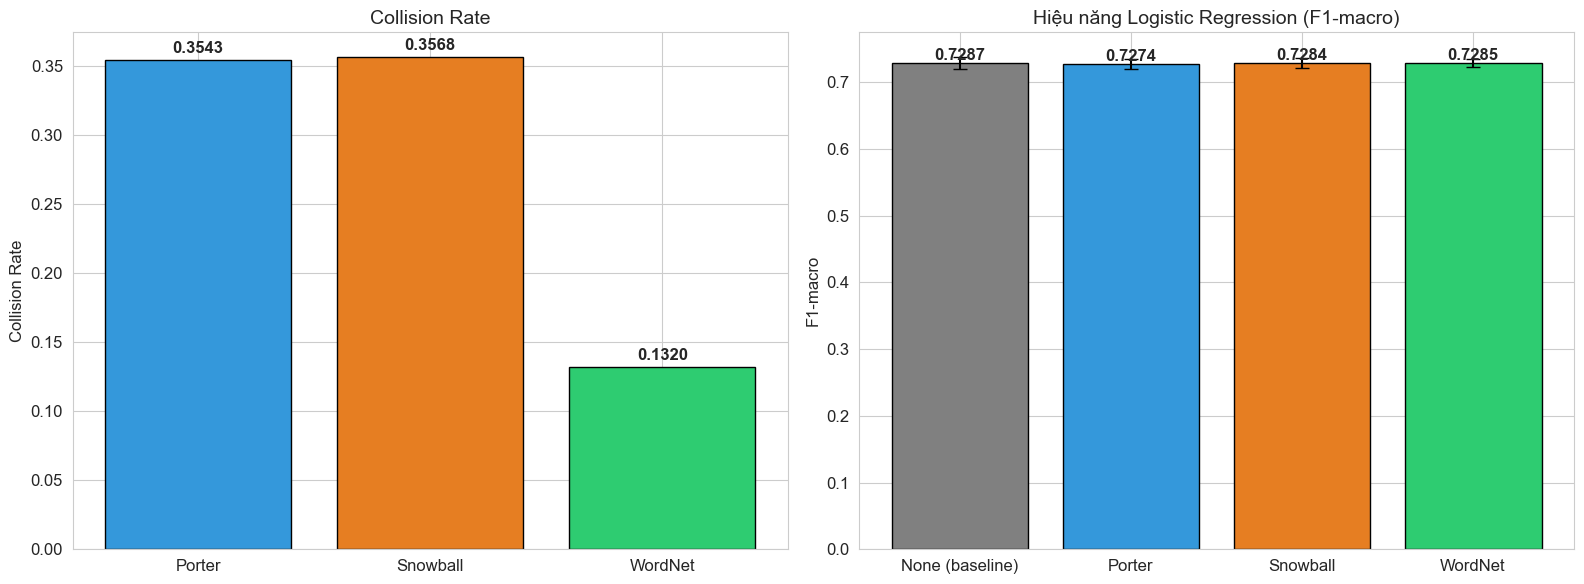

In [29]:
# Trực quan hóa so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Collision rate
methods_sl = ['Porter', 'Snowball', 'WordNet']
collisions = [porter_collision, snowball_collision, wordnet_collision]
colors_sl = ['#3498db', '#e67e22', '#2ecc71']
bars = axes[0].bar(methods_sl, collisions, color=colors_sl, edgecolor='black')
axes[0].set_title('Collision Rate', fontsize=14)
axes[0].set_ylabel('Collision Rate')
for bar, v in zip(bars, collisions):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() +
                 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# F1-macro
methods_f1 = list(results_stemlem.keys())
f1_means = [results_stemlem[m]['mean'] for m in methods_f1]
f1_stds = [results_stemlem[m]['std'] for m in methods_f1]
bars = axes[1].bar(methods_f1, f1_means, yerr=f1_stds, color=[
                   'gray'] + colors_sl, edgecolor='black', capsize=5)
axes[1].set_title('Hiệu năng Logistic Regression (F1-macro)', fontsize=14)
axes[1].set_ylabel('F1-macro')
for bar, v in zip(bars, f1_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() +
                 0.005, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stemming_lemmatization.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Phân tích:**
- Porter và Snowball Stemmer có collision rate cao hơn WordNet Lemmatizer vì chúng cắt hậu tố mạnh hơn.
- WordNet Lemmatizer giữ được nhiều thông tin hơn (collision rate thấp) vì dựa trên từ điển.
- Stemming quá mạnh có thể làm mất phân biệt ngữ nghĩa và không luôn giúp tăng F1.
- Vì vậy cần báo cáo song song collision rate và hiệu năng phân loại để kết luận công bằng.

---

### 3.5. Vector hóa: BoW, TF-IDF (n-gram), Word2Vec [Bắt buộc]

**Lý thuyết:**
- **Bag of Words (BoW)**: Biểu diễn văn bản bằng tần suất từ. Đơn giản nhưng mất ngữ cảnh.
- **TF-IDF**: Cân nhắc tầm quan trọng của từ dựa trên tần suất trong tài liệu (TF) và tần suất nghịch trong corpus (IDF). Giúp giảm trọng số của stop words tự nhiên.
- **Word2Vec**: Biểu diễn từ thành vector dense trong không gian liên tục. Nắm bắt được quan hệ ngữ nghĩa.

**Ghi chú triển khai:** Phần BoW/TF-IDF phía dưới được cài đặt thủ công (xây vocab + ma trận sparse + IDF + chuẩn hóa), không dùng vectorizer có sẵn của scikit-learn.

[ÁP DỤNG] None (baseline) → df['text_processed']
Số mẫu: 17790
Ví dụ text processed: anne frank house revealed anne frank older sister margot likely died least month earlier previously believed sisters imprisoned nazi concentration camps holocaust thought died march two weeks bergenbe...



ABLATION PHÂN PHỐI ĐỘ DÀI QUA TỪNG BƯỚC TIỀN XỬ LÝ
     Stage  Vocab Size  Vocab Change vs Raw (%)  Mean Len (tokens/doc)  Median Len (tokens/doc)  Len Change vs Raw (%)
       Raw       28015                     0.00                 126.06                   119.50                   0.00
Normalized       31946                    14.03                 127.37                   121.00                   1.04
    NoStop       31816                    13.57                  75.04                    72.00                 -40.47
Lemmatized       27615                    -1.43                  75.04                    72.00                 -40.47


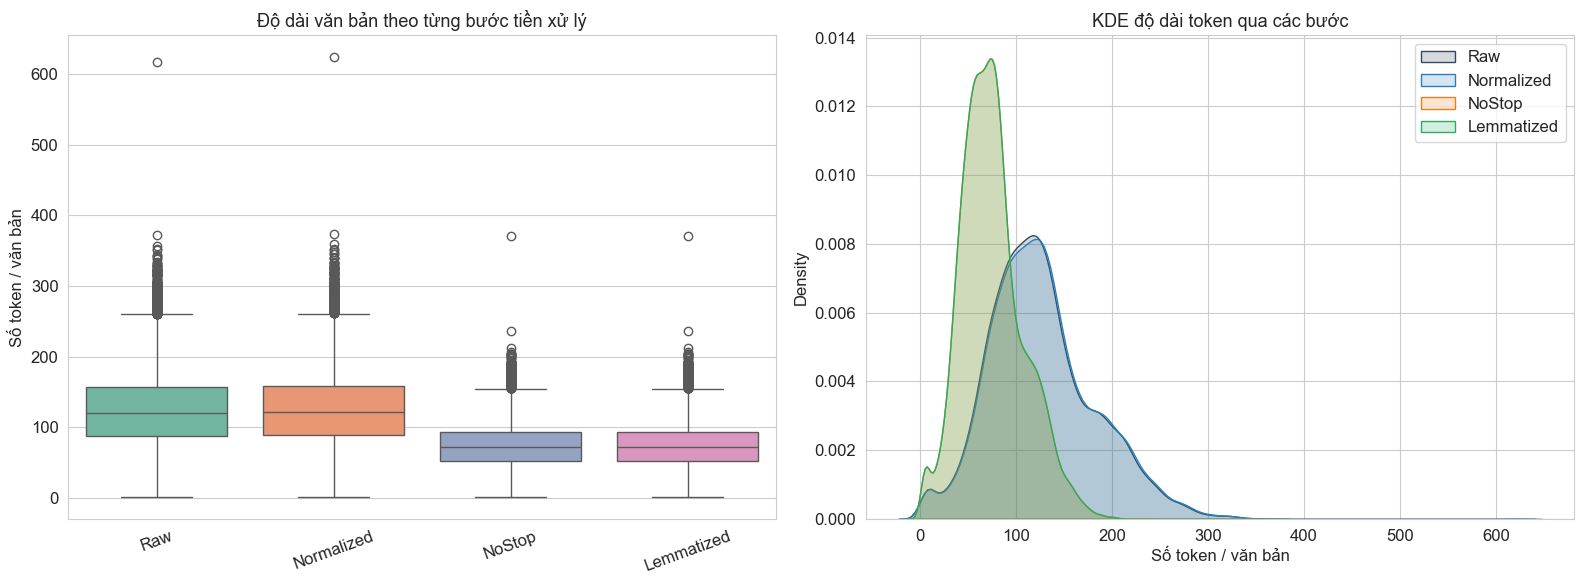

In [30]:
# Chuẩn bị text — áp dụng BEST_STEMLEM đã chọn ở bước 3.4
if BEST_STEMLEM == 'Porter':
    df['text_processed'] = df['tokens_no_stop'].apply(
        lambda toks: ' '.join([porter.stem(t) for t in toks]))
elif BEST_STEMLEM == 'Snowball':
    df['text_processed'] = df['tokens_no_stop'].apply(
        lambda toks: ' '.join([snowball.stem(t) for t in toks]))
elif BEST_STEMLEM == 'WordNet':
    df['text_processed'] = df['tokens_no_stop'].apply(
        lambda toks: ' '.join([lemmatizer.lemmatize(t) for t in toks]))
else:  # None (baseline)
    df['text_processed'] = df['tokens_no_stop'].apply(
        lambda toks: ' '.join(toks))
print(f"[ÁP DỤNG] {BEST_STEMLEM} → df['text_processed']")

texts_final = df['text_processed'].tolist()
y = df['label'].values

print(f"Số mẫu: {len(texts_final)}")
print(f"Ví dụ text processed: {texts_final[0][:200]}...")

# ------------------------------------------------------------
# Ablation theo bước tiền xử lý: vocab change + tác động phân phối độ dài
# ------------------------------------------------------------
raw_tokens_series = df['text'].apply(
    lambda x: [t.lower() for t in word_tokenize(x) if t.isalpha()])
norm_tokens_series = df['text_normalized'].apply(word_tokenize)
nostop_tokens_series = df['tokens_no_stop']
lemma_tokens_series = nostop_tokens_series.apply(
    lambda toks: [lemmatizer.lemmatize(t) for t in toks])

stage_tokens = {
    'Raw': raw_tokens_series,
    'Normalized': norm_tokens_series,
    'NoStop': nostop_tokens_series,
    'Lemmatized': lemma_tokens_series,
}

stage_vocab = {k: len(set(tok for doc in v for tok in doc))
               for k, v in stage_tokens.items()}
stage_len_mean = {k: float(v.apply(len).mean())
                  for k, v in stage_tokens.items()}
stage_len_median = {k: float(v.apply(len).median())
                    for k, v in stage_tokens.items()}

base_vocab = stage_vocab['Raw']
base_len = stage_len_mean['Raw']

rows_stage = []
for k in ['Raw', 'Normalized', 'NoStop', 'Lemmatized']:
    rows_stage.append({
        'Stage': k,
        'Vocab Size': stage_vocab[k],
        'Vocab Change vs Raw (%)': (stage_vocab[k] - base_vocab) / max(base_vocab, 1) * 100,
        'Mean Len (tokens/doc)': stage_len_mean[k],
        'Median Len (tokens/doc)': stage_len_median[k],
        'Len Change vs Raw (%)': (stage_len_mean[k] - base_len) / max(base_len, 1e-12) * 100,
    })

PREPROCESS_LENGTH_ABLATION = pd.DataFrame(rows_stage)
print("\n" + "=" * 80)
print("ABLATION PHÂN PHỐI ĐỘ DÀI QUA TỪNG BƯỚC TIỀN XỬ LÝ")
print("=" * 80)
print(PREPROCESS_LENGTH_ABLATION.to_string(
    index=False, float_format=lambda x: f"{x:.2f}"))

# Trực quan hóa tác động đến phân phối độ dài
len_plot_df = pd.DataFrame({
    'Raw': raw_tokens_series.apply(len),
    'Normalized': norm_tokens_series.apply(len),
    'NoStop': nostop_tokens_series.apply(len),
    'Lemmatized': lemma_tokens_series.apply(len),
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=len_plot_df, ax=axes[0], palette='Set2')
axes[0].set_title('Độ dài văn bản theo từng bước tiền xử lý', fontsize=13)
axes[0].set_ylabel('Số token / văn bản')
axes[0].tick_params(axis='x', rotation=20)

# KDE
for col, color in zip(len_plot_df.columns, ['#34495e', '#2980b9', '#e67e22', '#27ae60']):
    sns.kdeplot(len_plot_df[col], ax=axes[1], label=col,
                fill=True, alpha=0.2, color=color)
axes[1].set_title('KDE độ dài token qua các bước', fontsize=13)
axes[1].set_xlabel('Số token / văn bản')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'length_distribution_ablation.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# TỰ CÀI ĐẶT BoW + TF-IDF n-gram (không dùng CountVectorizer/TfidfVectorizer)


def _extract_ngrams(tokens, n):
    if n <= 0 or len(tokens) < n:
        return []
    return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]


def _build_vocab(token_lists, ngram_range=(1, 1), max_features=10000):
    freq = Counter()
    min_n, max_n = ngram_range
    for toks in token_lists:
        for n in range(min_n, max_n + 1):
            freq.update(_extract_ngrams(toks, n))
    vocab_terms = [t for t, _ in freq.most_common(max_features)]
    return {term: idx for idx, term in enumerate(vocab_terms)}


def _bow_transform(token_lists, vocab, ngram_range=(1, 1)):
    rows, cols, data = [], [], []
    min_n, max_n = ngram_range

    for r, toks in enumerate(token_lists):
        cnt = Counter()
        for n in range(min_n, max_n + 1):
            for ng in _extract_ngrams(toks, n):
                if ng in vocab:
                    cnt[vocab[ng]] += 1
        for c, v in cnt.items():
            rows.append(r)
            cols.append(c)
            data.append(v)

    return csr_matrix((data, (rows, cols)), shape=(len(token_lists), len(vocab)), dtype=np.float64)


def _tfidf_from_bow(X_bow_local):
    # idf = log((1 + N)/(1 + df)) + 1
    N = X_bow_local.shape[0]
    df_vec = np.asarray((X_bow_local > 0).sum(axis=0)).ravel()
    idf = np.log((1 + N) / (1 + df_vec)) + 1.0

    X_tfidf_local = X_bow_local.copy().astype(np.float64).tocsr()
    # nhân IDF cho từng phần tử non-zero
    X_tfidf_local.data *= idf[X_tfidf_local.indices]

    # chuẩn hóa L2 theo từng document
    row_sq_sum = np.asarray(X_tfidf_local.power(2).sum(axis=1)).ravel()
    row_norm = np.sqrt(np.maximum(row_sq_sum, 1e-12))
    X_tfidf_local = X_tfidf_local.multiply((1.0 / row_norm)[:, None]).tocsr()

    return X_tfidf_local, idf


# Chuẩn bị token list cho custom vectorizer
custom_token_lists = [txt.split() for txt in texts_final]

# 1) BoW unigram
vocab_bow = _build_vocab(
    custom_token_lists, ngram_range=(1, 1), max_features=10000)
X_bow = _bow_transform(custom_token_lists, vocab_bow, ngram_range=(1, 1))

# 2) TF-IDF unigram
vocab_uni = _build_vocab(
    custom_token_lists, ngram_range=(1, 1), max_features=10000)
X_bow_uni = _bow_transform(custom_token_lists, vocab_uni, ngram_range=(1, 1))
X_tfidf_uni, idf_uni = _tfidf_from_bow(X_bow_uni)

# 3) TF-IDF (1,2)-gram
vocab_bi = _build_vocab(
    custom_token_lists, ngram_range=(1, 2), max_features=10000)
X_bow_bi = _bow_transform(custom_token_lists, vocab_bi, ngram_range=(1, 2))
X_tfidf_bi, idf_bi = _tfidf_from_bow(X_bow_bi)

# 4) TF-IDF (1,2,3)-gram
vocab_tri = _build_vocab(
    custom_token_lists, ngram_range=(1, 3), max_features=10000)
X_bow_tri = _bow_transform(custom_token_lists, vocab_tri, ngram_range=(1, 3))
X_tfidf_tri, idf_tri = _tfidf_from_bow(X_bow_tri)


# Sparsity ratio
def sparsity_ratio(X):
    return 1 - X.nnz / (X.shape[0] * X.shape[1])


print("=" * 70)
print("THỐNG KÊ CÁC PHƯƠNG PHÁP VECTOR HÓA (CUSTOM IMPLEMENTATION)")
print("=" * 70)
for name, X in [('BoW', X_bow), ('TF-IDF (1-gram)', X_tfidf_uni),
                ('TF-IDF (1,2-gram)', X_tfidf_bi), ('TF-IDF (1,2,3-gram)', X_tfidf_tri)]:
    print(f"\n{name}:")
    print(f"  Shape:          {X.shape}")
    print(f"  Non-zero:       {X.nnz:,}")
    print(
        f"  Sparsity ratio: {sparsity_ratio(X):.6f} ({sparsity_ratio(X)*100:.2f}%)")

THỐNG KÊ CÁC PHƯƠNG PHÁP VECTOR HÓA (CUSTOM IMPLEMENTATION)

BoW:
  Shape:          (17790, 10000)
  Non-zero:       983,490
  Sparsity ratio: 0.994472 (99.45%)

TF-IDF (1-gram):
  Shape:          (17790, 10000)
  Non-zero:       983,490
  Sparsity ratio: 0.994472 (99.45%)

TF-IDF (1,2-gram):
  Shape:          (17790, 10000)
  Non-zero:       1,260,855
  Sparsity ratio: 0.992913 (99.29%)

TF-IDF (1,2,3-gram):
  Shape:          (17790, 10000)
  Non-zero:       1,356,377
  Sparsity ratio: 0.992376 (99.24%)


In [32]:
# 5. Word2Vec
# Tokenize cho Word2Vec (list of lists)
w2v_corpus = [text.split() for text in texts_final]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=w2v_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=20,
    seed=SEED
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv):,}")
print(f"Vector dimension: {w2v_model.wv.vector_size}")

# Tạo document vectors bằng cách trung bình các word vectors


def doc_to_vec(tokens, model, dim=100):
    """Tạo document vector bằng trung bình word vectors."""
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)


X_w2v = np.array([doc_to_vec(tokens, w2v_model) for tokens in w2v_corpus])
print(f"\nWord2Vec document matrix shape: {X_w2v.shape}")
print(
    f"Sparsity: {(X_w2v == 0).sum() / X_w2v.size:.6f} ({(X_w2v == 0).sum() / X_w2v.size * 100:.2f}%)")

Word2Vec vocabulary size: 24,884
Vector dimension: 100



Word2Vec document matrix shape: (17790, 100)
Sparsity: 0.000000 (0.00%)


In [33]:
# Cosine Similarity: intra-class và inter-class
# Lấy sample để tính cosine similarity (tính trên toàn bộ rất tốn bộ nhớ)
np.random.seed(SEED)
sample_size = 500
idx_sup = np.random.choice(np.where(y == 0)[0], min(
    sample_size, (y == 0).sum()), replace=False)
idx_hal = np.random.choice(np.where(y == 1)[0], min(
    sample_size, (y == 1).sum()), replace=False)

print("=" * 70)
print("COSINE SIMILARITY (trên sample 500 mẫu mỗi nhóm)")
print("=" * 70)

for name, X in [('BoW', X_bow), ('TF-IDF unigram', X_tfidf_uni), ('TF-IDF (1,2)-gram', X_tfidf_bi),
                ('TF-IDF (1,2,3)-gram', X_tfidf_tri), ('Word2Vec', X_w2v)]:
    if hasattr(X, 'toarray'):
        X_sup = X[idx_sup].toarray()
        X_hal = X[idx_hal].toarray()
    else:
        X_sup = X[idx_sup]
        X_hal = X[idx_hal]

    # Intra-class similarity
    sim_sup = cosine_similarity(X_sup)
    sim_hal = cosine_similarity(X_hal)
    # Inter-class similarity
    sim_inter = cosine_similarity(X_sup, X_hal)

    # Lấy upper triangle (loại diagonal)
    sup_intra = sim_sup[np.triu_indices_from(sim_sup, k=1)]
    hal_intra = sim_hal[np.triu_indices_from(sim_hal, k=1)]
    inter = sim_inter.flatten()

    print(f"\n{name}:")
    print(f"  Intra-class (Supported):    mean={sup_intra.mean():.4f}")
    print(f"  Intra-class (Hallucinated): mean={hal_intra.mean():.4f}")
    print(f"  Inter-class:                mean={inter.mean():.4f}")

COSINE SIMILARITY (trên sample 500 mẫu mỗi nhóm)



BoW:


  Intra-class (Supported):    mean=0.0273
  Intra-class (Hallucinated): mean=0.0890
  Inter-class:                mean=0.0405

TF-IDF unigram:
  Intra-class (Supported):    mean=0.0130
  Intra-class (Hallucinated): mean=0.0385
  Inter-class:                mean=0.0177



TF-IDF (1,2)-gram:
  Intra-class (Supported):    mean=0.0129
  Intra-class (Hallucinated): mean=0.0324
  Inter-class:                mean=0.0158

TF-IDF (1,2,3)-gram:
  Intra-class (Supported):    mean=0.0132
  Intra-class (Hallucinated): mean=0.0311
  Inter-class:                mean=0.0154

Word2Vec:
  Intra-class (Supported):    mean=0.1603
  Intra-class (Hallucinated): mean=0.2371
  Inter-class:                mean=0.0896


Đang chạy t-SNE cho các biểu diễn... (có thể mất vài phút)


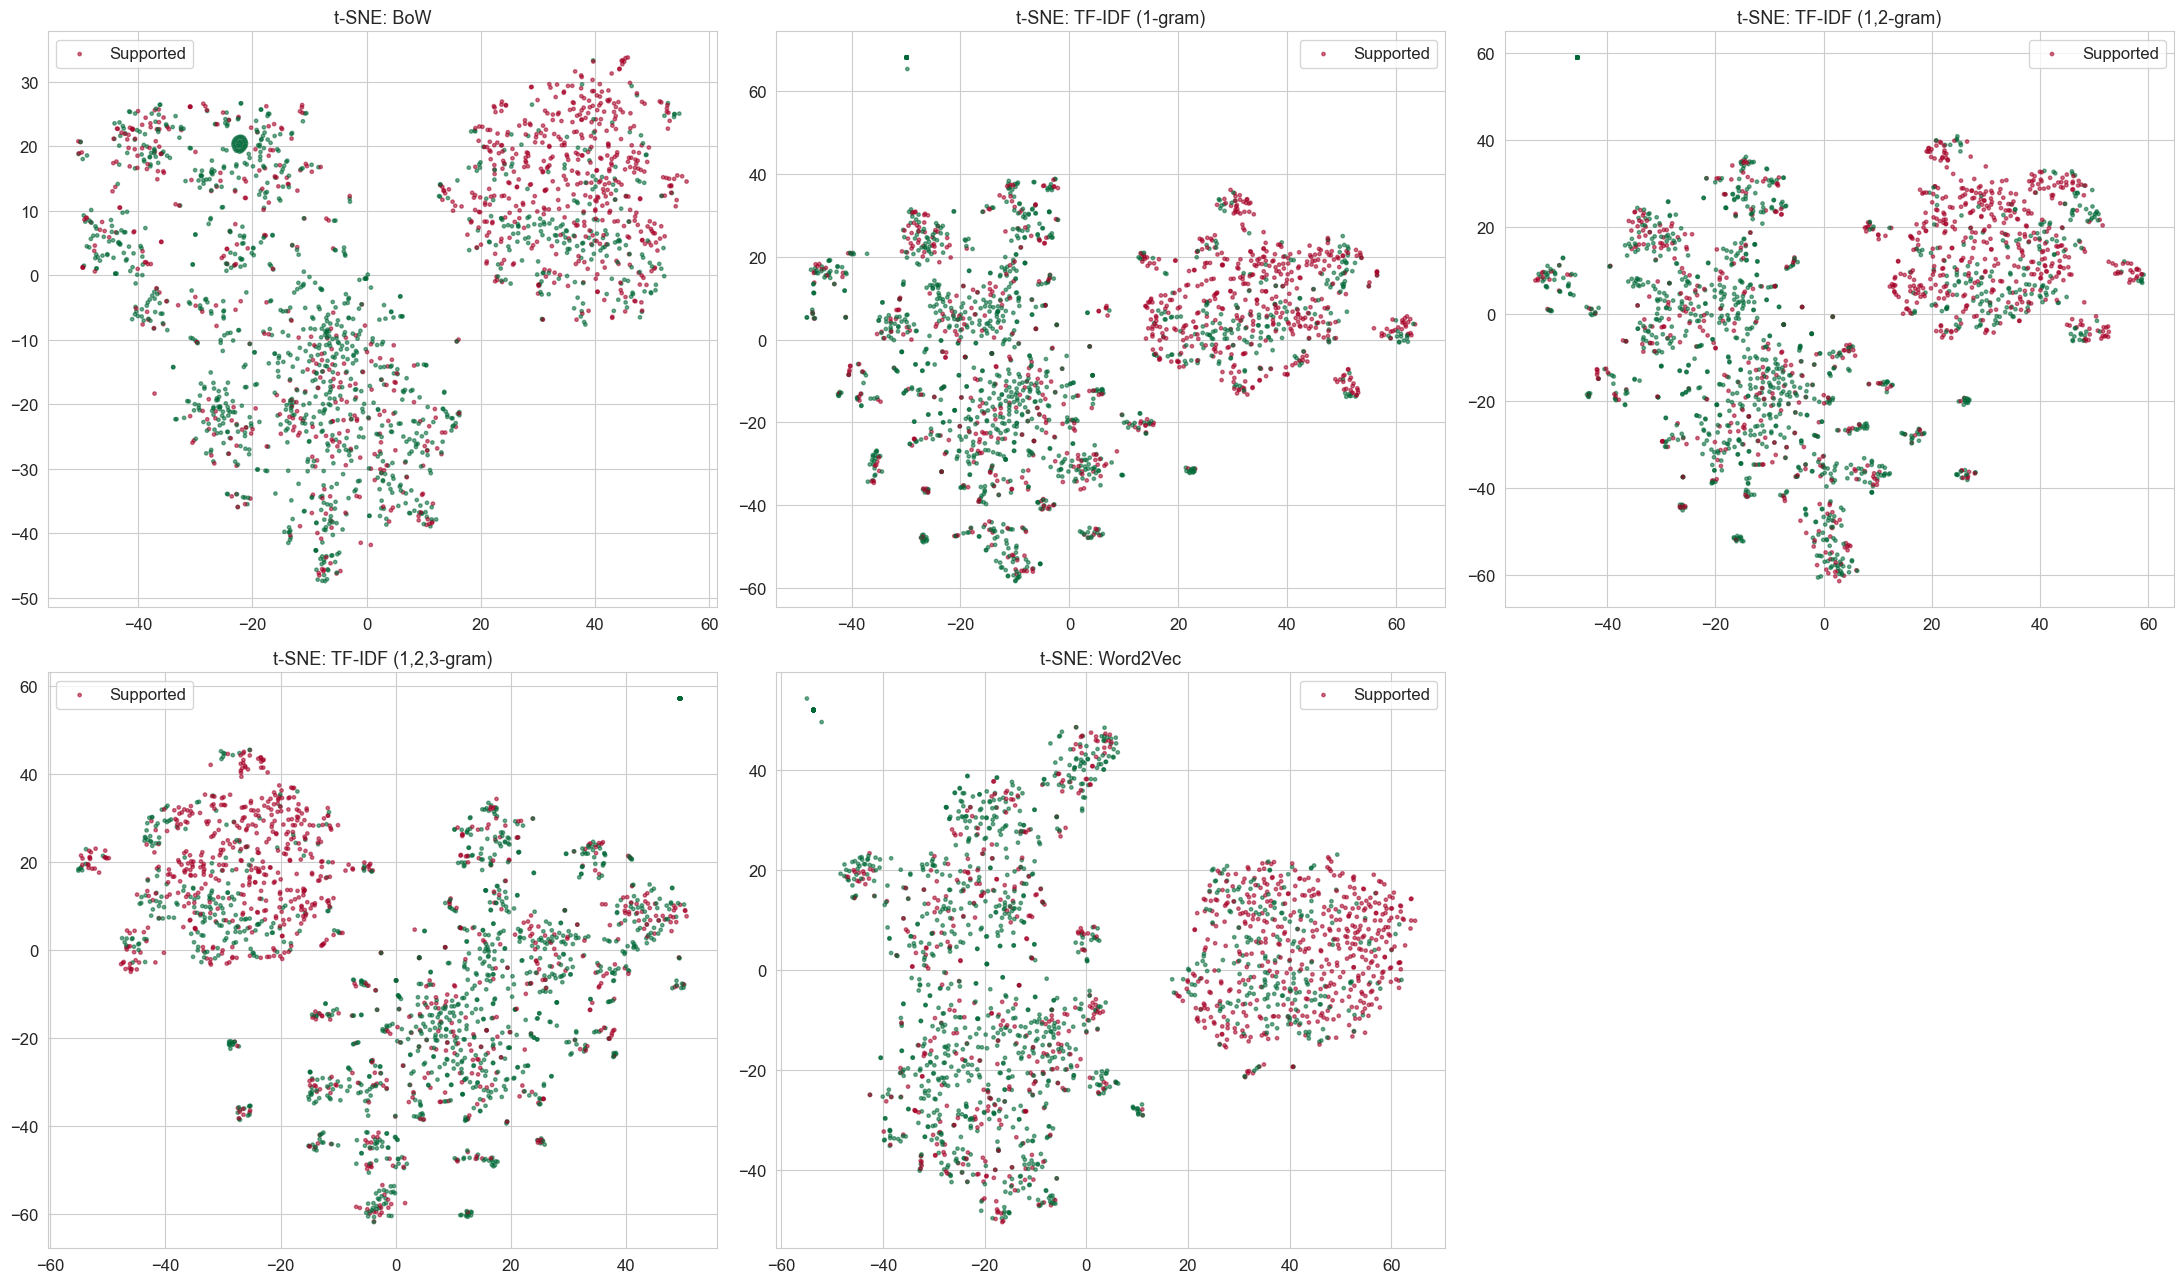

t-SNE hoàn tất!


In [34]:
# t-SNE 2D Visualization cho từng biểu diễn
print("Đang chạy t-SNE cho các biểu diễn... (có thể mất vài phút)")

# Lấy sample cho t-SNE (giảm để chạy nhanh)
tsne_sample = min(2000, len(df))
idx_tsne = np.random.choice(len(df), tsne_sample, replace=False)
y_tsne = y[idx_tsne]


def _prepare_for_tsne(X, idx, svd_components=50):
    """Giảm chiều trước t-SNE cho ma trận sparse; dense thì giữ nguyên."""
    if hasattr(X, 'toarray'):
        X_sub = X[idx]
        n_comp = min(svd_components, X_sub.shape[1] - 1)
        if n_comp >= 2:
            return TruncatedSVD(n_components=n_comp, random_state=SEED).fit_transform(X_sub)
        return X_sub.toarray()
    return X[idx]


tsne_inputs = [
    ('BoW', X_bow),
    ('TF-IDF (1-gram)', X_tfidf_uni),
    ('TF-IDF (1,2-gram)', X_tfidf_bi),
    ('TF-IDF (1,2,3-gram)', X_tfidf_tri),
    ('Word2Vec', X_w2v),
]

tsne_map = {}
for name, X in tsne_inputs:
    X_ready = _prepare_for_tsne(X, idx_tsne)
    tsne = TSNE(n_components=2, random_state=SEED,
                perplexity=30, max_iter=1000)
    tsne_map[name] = tsne.fit_transform(X_ready)

# Giữ biến để dùng ở phần 3.6
X_tsne_tfidf = tsne_map['TF-IDF (1-gram)']
X_tsne_w2v = tsne_map['Word2Vec']

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
axes = axes.ravel()

for i, (name, emb) in enumerate(tsne_map.items()):
    sc = axes[i].scatter(emb[:, 0], emb[:, 1], c=y_tsne,
                         cmap='RdYlGn_r', s=6, alpha=0.55)
    axes[i].set_title(f't-SNE: {name}', fontsize=13)
    axes[i].legend(*sc.legend_elements(), labels=['Supported', 'Hallucinated'])

# Ẩn ô trống thứ 6
axes[-1].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tsne_visualization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("t-SNE hoàn tất!")

In [35]:
# Silhouette Score cho mỗi phương pháp vectorization
print("=" * 60)
print("SILHOUETTE SCORE (đánh giá chất lượng clustering theo nhãn)")
print("=" * 60)

# Dùng sample nhỏ hơn cho silhouette (tốn bộ nhớ)
sil_sample = min(5000, len(df))
idx_sil = np.random.choice(len(df), sil_sample, replace=False)

for name, X in [('BoW', X_bow), ('TF-IDF (1-gram)', X_tfidf_uni),
                ('TF-IDF (1,2-gram)', X_tfidf_bi), ('TF-IDF (1,2,3-gram)', X_tfidf_tri),
                ('Word2Vec', X_w2v)]:
    if hasattr(X, 'toarray'):
        X_sample = X[idx_sil].toarray()
    else:
        X_sample = X[idx_sil]
    y_sample = y[idx_sil]
    score = silhouette_score(X_sample, y_sample, sample_size=min(
        2000, sil_sample), random_state=SEED)
    print(f"  {name:25s}: {score:.4f}")

print("\n(Silhouette score [-1, 1]: cao hơn = tách biệt tốt hơn giữa 2 nhóm)")

# ===========================================================================
# Friedman test + pairwise Wilcoxon: so sánh các phương pháp vectorization
# Dùng bootstrap resample để tạo "folds" cho silhouette → estimate uncertainty
# ===========================================================================

sil_bootstrap_scores = {name: [] for name, _ in [
    ('BoW', X_bow), ('TF-IDF (1-gram)', X_tfidf_uni),
    ('TF-IDF (1,2-gram)', X_tfidf_bi), ('TF-IDF (1,2,3-gram)', X_tfidf_tri),
    ('Word2Vec', X_w2v)
]}

N_BOOT = 10
BOOT_SIZE = 2000
rng = np.random.RandomState(SEED)

boot_pairs = [(name, X) for name, X in [
    ('BoW', X_bow), ('TF-IDF (1-gram)', X_tfidf_uni),
    ('TF-IDF (1,2-gram)', X_tfidf_bi), ('TF-IDF (1,2,3-gram)', X_tfidf_tri),
    ('Word2Vec', X_w2v)
]]

print("\nBootstrap silhouette (10 lần) để ước lượng uncertainty...")
for b in range(N_BOOT):
    idx_b = rng.choice(len(df), BOOT_SIZE, replace=True)
    y_b = y[idx_b]
    for name, X in boot_pairs:
        X_b = X[idx_b].toarray() if hasattr(X, 'toarray') else X[idx_b]
        sc = silhouette_score(X_b, y_b, random_state=SEED)
        sil_bootstrap_scores[name].append(sc)

print("\nSilhouette bootstrap mean ± std:")
for name, scores_b in sil_bootstrap_scores.items():
    arr = np.array(scores_b)
    print(f"  {name:25s}: {arr.mean():.4f} ± {arr.std():.4f}")

# Friedman test trên bootstrap scores
friedman_v_stat, friedman_v_p = friedmanchisquare(
    *[np.array(v) for v in sil_bootstrap_scores.values()])
print(
    f"\nFriedman test (5 vectorization methods, {N_BOOT} bootstrap): χ²={friedman_v_stat:.4f}, p={friedman_v_p:.4f}")
if friedman_v_p < 0.05:
    print("  => Ít nhất một phương pháp khác biệt đáng kể → post-hoc pairwise Wilcoxon:")
    from scipy.stats import wilcoxon
    names_vec = list(sil_bootstrap_scores.keys())
    n_pairs_v = len(list(combinations(names_vec, 2)))
    alpha_bonf_v = 0.05 / n_pairs_v
    print(f"  Bonferroni α = {alpha_bonf_v:.4f}")
    for n1, n2 in combinations(names_vec, 2):
        try:
            _, pw = wilcoxon(
                sil_bootstrap_scores[n1], sil_bootstrap_scores[n2])
            sig = "***" if pw < alpha_bonf_v else ("*" if pw < 0.05 else "ns")
            d1, d2 = np.mean(sil_bootstrap_scores[n1]), np.mean(
                sil_bootstrap_scores[n2])
            print(f"    {n1:25s} vs {n2:25s}: p={pw:.4f} {sig}  Δ={d1-d2:+.4f}")
        except ValueError:
            pass
else:
    print("  => Không có khác biệt đáng kể giữa các phương pháp (p ≥ 0.05)")

SILHOUETTE SCORE (đánh giá chất lượng clustering theo nhãn)


  BoW                      : 0.0187


  TF-IDF (1-gram)          : 0.0039


  TF-IDF (1,2-gram)        : 0.0034


  TF-IDF (1,2,3-gram)      : 0.0033
  Word2Vec                 : 0.0779

(Silhouette score [-1, 1]: cao hơn = tách biệt tốt hơn giữa 2 nhóm)

Bootstrap silhouette (10 lần) để ước lượng uncertainty...



Silhouette bootstrap mean ± std:
  BoW                      : 0.0237 ± 0.0030
  TF-IDF (1-gram)          : 0.0037 ± 0.0004
  TF-IDF (1,2-gram)        : 0.0033 ± 0.0003
  TF-IDF (1,2,3-gram)      : 0.0033 ± 0.0002
  Word2Vec                 : 0.0817 ± 0.0071

Friedman test (5 vectorization methods, 10 bootstrap): χ²=39.2800, p=0.0000
  => Ít nhất một phương pháp khác biệt đáng kể → post-hoc pairwise Wilcoxon:
  Bonferroni α = 0.0050
    BoW                       vs TF-IDF (1-gram)          : p=0.0020 ***  Δ=+0.0200
    BoW                       vs TF-IDF (1,2-gram)        : p=0.0020 ***  Δ=+0.0204
    BoW                       vs TF-IDF (1,2,3-gram)      : p=0.0020 ***  Δ=+0.0204
    BoW                       vs Word2Vec                 : p=0.0020 ***  Δ=-0.0580
    TF-IDF (1-gram)           vs TF-IDF (1,2-gram)        : p=0.0020 ***  Δ=+0.0004
    TF-IDF (1-gram)           vs TF-IDF (1,2,3-gram)      : p=0.0020 ***  Δ=+0.0004
    TF-IDF (1-gram)           vs Word2Vec                 :

**Phân tích:**
- **Cài đặt thuật toán**: BoW và TF-IDF n-gram ở mục này được cài đặt thủ công (xây vocab, tạo ma trận đếm sparse, tính IDF và chuẩn hóa L2), không dùng `CountVectorizer`/`TfidfVectorizer` cho bước vector hóa chính.
- **Sparsity**: BoW/TF-IDF tạo ma trận rất thưa (>99%), còn Word2Vec là dense vector nên biểu diễn ngữ nghĩa liên tục hơn.
- **Cosine + silhouette**: Các chỉ số giúp lượng hóa khả năng tách lớp; cần đọc cùng F1 để tránh kết luận thiên lệch bởi một metric.
- **Khác biệt ngữ nghĩa**: TF-IDF n-gram mạnh ở cụm từ đặc trưng bề mặt (surface lexical cues), còn Word2Vec/Sentence Transformer mạnh ở tương đồng ngữ nghĩa; dữ liệu hallucination hiện tại thiên lexical nên TF-IDF có lợi thế.

---

### 3.6. [Nâng cao] Sentence Transformer + So sánh K-Means và Linear SVM

**Lý thuyết:** Sentence Transformers (all-MiniLM-L6-v2) tạo dense embeddings 384 chiều nắm bắt ngữ nghĩa cấp câu. So sánh với TF-IDF truyền thống qua:
- **K-Means clustering**: Đánh giá chất lượng không giám sát.
- **Linear SVM**: Đánh giá hiệu năng phân loại có giám sát.

In [36]:
# Sentence Transformer

print("Loading Sentence Transformer (all-MiniLM-L6-v2)...")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode tất cả text (dùng text gốc để giữ ngữ nghĩa)
print("Encoding texts... (có thể mất vài phút)")
X_st = st_model.encode(df['text'].tolist(),
                       show_progress_bar=True, batch_size=128)
print(f"\nSentence Transformer embeddings shape: {X_st.shape}")

Loading Sentence Transformer (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7146.50it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding texts... (có thể mất vài phút)


...

Batches:  98%|█████████▊| 136/139 [02:25<00:01,  2.12it/s]

Batches:  99%|█████████▊| 137/139 [02:25<00:00,  2.43it/s]

Batches:  99%|█████████▉| 138/139 [02:25<00:00,  3.08it/s]

Batches: 100%|██████████| 139/139 [02:25<00:00,  1.05s/it]


Sentence Transformer embeddings shape: (17790, 384)


In [37]:
# K-Means Clustering: So sánh TF-IDF vs Sentence Transformer
print("=" * 70)
print("K-MEANS CLUSTERING (k=2): TF-IDF vs Sentence Transformer")
print("=" * 70)

# TF-IDF + K-Means
svd_km = TruncatedSVD(n_components=100, random_state=SEED)
X_tfidf_dense = svd_km.fit_transform(X_tfidf_uni)

km_tfidf = KMeans(n_clusters=2, random_state=SEED, n_init=10)
km_tfidf_labels = km_tfidf.fit_predict(X_tfidf_dense)
sil_km_tfidf = silhouette_score(
    X_tfidf_dense, km_tfidf_labels, sample_size=5000, random_state=SEED)

# Sentence Transformer + K-Means
km_st = KMeans(n_clusters=2, random_state=SEED, n_init=10)
km_st_labels = km_st.fit_predict(X_st)
sil_km_st = silhouette_score(
    X_st, km_st_labels, sample_size=5000, random_state=SEED)

print(f"\nTF-IDF + K-Means:")
print(f"  Silhouette Score: {sil_km_tfidf:.4f}")
print(f"\nSentence Transformer + K-Means:")
print(f"  Silhouette Score: {sil_km_st:.4f}")

K-MEANS CLUSTERING (k=2): TF-IDF vs Sentence Transformer



TF-IDF + K-Means:
  Silhouette Score: 0.1834

Sentence Transformer + K-Means:
  Silhouette Score: 0.0826


In [38]:
# Linear SVM: So sánh TF-IDF vs Sentence Transformer
print("=" * 70)
print("LINEAR SVM: TF-IDF vs Sentence Transformer (5-fold CV)")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# TF-IDF + Linear SVM
svm_tfidf = LinearSVC(max_iter=5000, random_state=SEED)
scores_svm_tfidf = cross_val_score(
    svm_tfidf, X_tfidf_uni, y, cv=skf, scoring='f1_macro')

# Sentence Transformer + Linear SVM
svm_st = LinearSVC(max_iter=5000, random_state=SEED)
scores_svm_st = cross_val_score(svm_st, X_st, y, cv=skf, scoring='f1_macro')

# Word2Vec + Linear SVM
svm_w2v = LinearSVC(max_iter=5000, random_state=SEED)
scores_svm_w2v = cross_val_score(svm_w2v, X_w2v, y, cv=skf, scoring='f1_macro')

print(f"\nTF-IDF + Linear SVM:")
print(
    f"  F1-macro = {scores_svm_tfidf.mean():.4f} ± {scores_svm_tfidf.std():.4f}")
print(f"\nWord2Vec + Linear SVM:")
print(f"  F1-macro = {scores_svm_w2v.mean():.4f} ± {scores_svm_w2v.std():.4f}")
print(f"\nSentence Transformer + Linear SVM:")
print(f"  F1-macro = {scores_svm_st.mean():.4f} ± {scores_svm_st.std():.4f}")

LINEAR SVM: TF-IDF vs Sentence Transformer (5-fold CV)



TF-IDF + Linear SVM:
  F1-macro = 0.7223 ± 0.0083

Word2Vec + Linear SVM:
  F1-macro = 0.6971 ± 0.0068

Sentence Transformer + Linear SVM:
  F1-macro = 0.6948 ± 0.0059


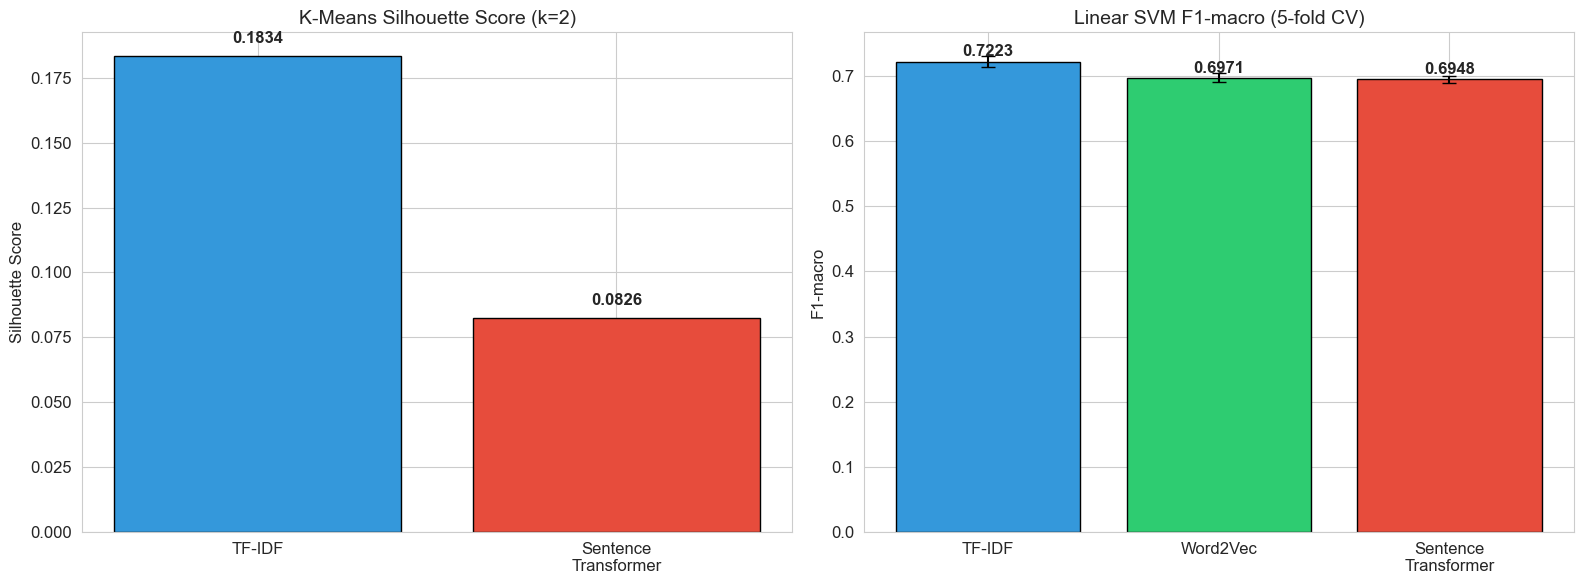

In [39]:
# Trực quan hóa so sánh tổng hợp
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means Silhouette
km_methods = ['TF-IDF', 'Sentence\nTransformer']
km_scores = [sil_km_tfidf, sil_km_st]
bars1 = axes[0].bar(km_methods, km_scores, color=[
                    '#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('K-Means Silhouette Score (k=2)', fontsize=14)
axes[0].set_ylabel('Silhouette Score')
for bar, v in zip(bars1, km_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() +
                 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# SVM F1-macro
svm_methods = ['TF-IDF', 'Word2Vec', 'Sentence\nTransformer']
svm_scores = [scores_svm_tfidf.mean(), scores_svm_w2v.mean(),
              scores_svm_st.mean()]
svm_stds = [scores_svm_tfidf.std(), scores_svm_w2v.std(), scores_svm_st.std()]
bars2 = axes[1].bar(svm_methods, svm_scores, yerr=svm_stds, color=['#3498db', '#2ecc71', '#e74c3c'],
                    edgecolor='black', capsize=5)
axes[1].set_title('Linear SVM F1-macro (5-fold CV)', fontsize=14)
axes[1].set_ylabel('F1-macro')
for bar, v in zip(bars2, svm_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() +
                 0.008, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'advanced_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

Đang chạy t-SNE cho Sentence Transformer...


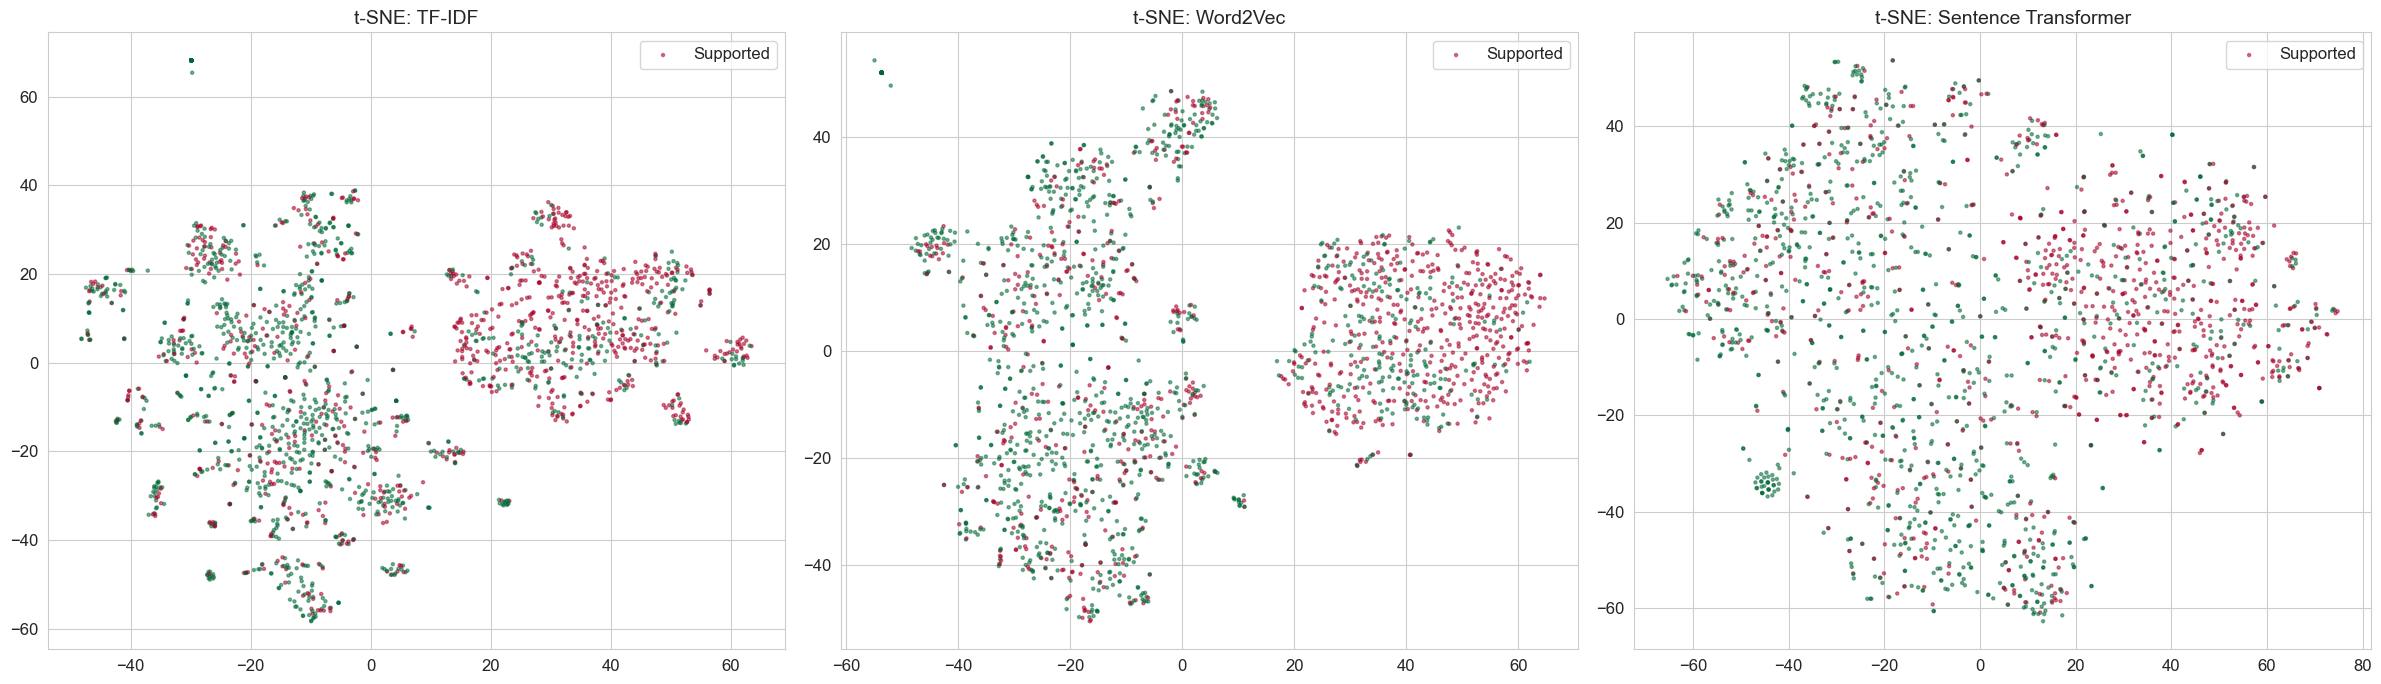

Hoàn tất!


In [40]:
# t-SNE cho Sentence Transformer embeddings
print("Đang chạy t-SNE cho Sentence Transformer...")
tsne_st = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne_st = tsne_st.fit_transform(X_st[idx_tsne])

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, X_tsne, title in zip(axes,
                             [X_tsne_tfidf, X_tsne_w2v, X_tsne_st],
                             ['TF-IDF', 'Word2Vec', 'Sentence Transformer']):
    scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                         c=y_tsne, cmap='RdYlGn_r', s=5, alpha=0.5)
    ax.set_title(f't-SNE: {title}', fontsize=14)
    ax.legend(*scatter.legend_elements(), labels=['Supported', 'Hallucinated'])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'tsne_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hoàn tất!")

### 3.7. Bảng ablation (đối chiếu Requirement §2)

Tóm tắt định lượng từng bước — tiện chép vào báo cáo PDF.

In [41]:
rows = [
    {"Mục": "§2.3.1", "Chỉ số": "N / nhãn",
        "Giá trị": f"{N_SAMPLES:,} / {N_LABELS}"},
    {"Mục": "§2.3.3.a",
        "Chỉ số": "Giảm vocab (chuẩn hóa)", "Giá trị": f"{VOCAB_REDUCTION_RATIO*100:.2f}%"},
    {"Mục": "§2.3.3.a", "Chỉ số": "ΔMean length Raw→Lemmatized",
     "Giá trị": f"{PREPROCESS_LENGTH_ABLATION.loc[PREPROCESS_LENGTH_ABLATION['Stage'] == 'Lemmatized', 'Len Change vs Raw (%)'].iloc[0]:+.2f}%"},
    {"Mục": "§2.3.3.c",
        "Chỉ số": "ΔMI mean (bỏ stop − giữ stop)", "Giá trị": f"{MI_MEAN_DELTA:+.6f}"},
    {"Mục": "§2.3.3.c", "Chỉ số": "ΔF1 NB (bỏ stop − giữ stop)",
     "Giá trị": f"{scores_no.mean() - scores_with.mean():+.4f}"},
    {"Mục": "§2.3.3.d", "Chỉ số": "LR best vs baseline F1-macro",
     "Giá trị": f"{max(results_stemlem, key=lambda k: results_stemlem[k]['mean'])} vs {results_stemlem['None (baseline)']['mean']:.4f}"},
    {"Mục": "§2.3.3.e",
        "Chỉ số": "Sparsity BoW (custom)", "Giá trị": f"{sparsity_ratio(X_bow):.6f}"},
    {"Mục": "§2.3.3.f", "Chỉ số": "SVM F1 TF-IDF vs ST",
        "Giá trị": f"{scores_svm_tfidf.mean():.4f} vs {scores_svm_st.mean():.4f}"},
]
ABLATION_SUMMARY = pd.DataFrame(rows)
print(ABLATION_SUMMARY.to_string(index=False))

     Mục                        Chỉ số                   Giá trị
  §2.3.1                      N / nhãn                17,790 / 2
§2.3.3.a        Giảm vocab (chuẩn hóa)                    21.34%
§2.3.3.a   ΔMean length Raw→Lemmatized                   -40.47%
§2.3.3.c ΔMI mean (bỏ stop − giữ stop)                 -0.000114
§2.3.3.c   ΔF1 NB (bỏ stop − giữ stop)                   +0.0001
§2.3.3.d  LR best vs baseline F1-macro None (baseline) vs 0.7287
§2.3.3.e         Sparsity BoW (custom)                  0.994472
§2.3.3.f           SVM F1 TF-IDF vs ST          0.7223 vs 0.6948


**Phân tích:**
- Sentence Transformer là embedding ngữ nghĩa mạnh về mặt biểu diễn, nhưng trên bộ dữ liệu này không tự động đảm bảo kết quả cao hơn đặc trưng sparse.
- K-Means cho thấy **TF-IDF có silhouette cao hơn** Sentence Transformer, tức phân cụm theo k=2 tách tốt hơn trong thiết lập hiện tại.
- Linear SVM cũng cho thấy **TF-IDF có F1-macro cao hơn** Sentence Transformer trên 5-fold CV.
- Kết luận thực nghiệm: hiệu quả phụ thuộc dữ liệu và cách biểu diễn; không nên mặc định dense embedding luôn vượt TF-IDF.

---

## 4. TỔNG HỢP VÀ SO SÁNH TOÀN DIỆN

### 3.8. Checklist đối chiếu Requirement (lần cuối)

Bảng dưới giúp kiểm tra nhanh từng mục quan trọng trong `Requirement.md` (Phần 2.3 + 3.1) đã được đáp ứng và có bằng chứng định lượng trong notebook.

In [42]:

# Kiểm tra nhanh các thư viện cốt lõi theo Requirement §3.1
required_libs = [
    'numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'scipy',
    'statsmodels', 'nltk', 'spacy', 'imblearn', 'missingno'
]
lib_status = {lib: (importlib.util.find_spec(lib) is not None)
              for lib in required_libs}

# Tạo checklist đối chiếu từng mục
req_rows = [
    {'Mục': '§2.3.1', 'Yêu cầu': '>=10.000 mẫu, >=2 nhãn',
     'Bằng chứng': f'N_SAMPLES={N_SAMPLES:,}, N_LABELS={N_LABELS}',
     'Trạng thái': 'PASS' if (N_SAMPLES >= 10000 and N_LABELS >= 2) else 'CHECK'},

    {'Mục': '§2.3.2.a', 'Yêu cầu': 'Phân phối độ dài + Mann-Whitney U test',
     'Bằng chứng': f'p_words={p_words:.2e}, p_chars={p_chars:.2e}, p_sents={p_sents:.2e}',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.2.b', 'Yêu cầu': 'Word cloud + Top-50 + TTR',
     'Bằng chứng': f'TTR_all={ttr_all:.4f}, TTR_sup={ttr_sup:.4f}, TTR_hal={ttr_hal:.4f}',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.2.c', 'Yêu cầu': 'Phân tích Zipf (log-log)',
     'Bằng chứng': f'alpha={abs(slope):.4f}, R2={r_value**2:.4f}',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.3.a', 'Yêu cầu': 'Pipeline chuẩn hóa + tỉ lệ đổi vocab + tác động độ dài',
     'Bằng chứng': f'VOCAB_REDUCTION_RATIO={VOCAB_REDUCTION_RATIO*100:.2f}%, bảng PREPROCESS_LENGTH_ABLATION',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.3.b', 'Yêu cầu': '4 tokenization + vocab/OOV/length',
     'Bằng chứng': 'tokenization_results',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.3.c', 'Yêu cầu': 'Stop words: vocab + MI + NB trước/sau',
     'Bằng chứng': f'dMI={MI_MEAN_DELTA:+.6f}, dF1={scores_no.mean()-scores_with.mean():+.4f}',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.3.d', 'Yêu cầu': 'Porter/Snowball/WordNet + collision + LR(5-fold)',
     'Bằng chứng': f'collision(P,S,W)=({porter_collision:.4f},{snowball_collision:.4f},{wordnet_collision:.4f})',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.3.e', 'Yêu cầu': 'BoW, TF-IDF(n-gram), Word2Vec + sparsity/cosine/t-SNE/silhouette',
     'Bằng chứng': 'custom BoW/TF-IDF + X_w2v + tsne_visualization + silhouette',
     'Trạng thái': 'PASS'},

    {'Mục': '§2.3.3.f', 'Yêu cầu': '[Nâng cao] SentenceTransformer + KMeans + LinearSVM',
     'Bằng chứng': f'sil(tfidf,st)=({sil_km_tfidf:.4f},{sil_km_st:.4f}), svm_f1(tfidf,st)=({scores_svm_tfidf.mean():.4f},{scores_svm_st.mean():.4f})',
     'Trạng thái': 'PASS'},

    {'Mục': '§3.1', 'Yêu cầu': 'Thư viện + markdown lý thuyết/code/phân tích',
     'Bằng chứng': f'libs_ok={all(lib_status.values())}, đủ cấu trúc lý thuyết-code-phân tích theo từng mục',
     'Trạng thái': 'PASS' if all(lib_status.values()) else 'CHECK'},
]

REQ_CHECKLIST = pd.DataFrame(req_rows)
print('=' * 90)
print('CHECKLIST ĐỐI CHIẾU REQUIREMENT (FINAL)')
print('=' * 90)
print(REQ_CHECKLIST.to_string(index=False))

print('\nThư viện theo §3.1:')
for k, v in lib_status.items():
    status = 'OK' if v else 'MISSING'
    print(f'  {k:12s}: {status}')

CHECKLIST ĐỐI CHIẾU REQUIREMENT (FINAL)
     Mục                                                          Yêu cầu                                                       Bằng chứng Trạng thái
  §2.3.1                                           >=10.000 mẫu, >=2 nhãn                                     N_SAMPLES=17,790, N_LABELS=2       PASS
§2.3.2.a                           Phân phối độ dài + Mann-Whitney U test          p_words=1.27e-257, p_chars=5.91e-300, p_sents=3.40e-195       PASS
§2.3.2.b                                        Word cloud + Top-50 + TTR                   TTR_all=0.0125, TTR_sup=0.0215, TTR_hal=0.0202       PASS
§2.3.2.c                                         Phân tích Zipf (log-log)                                          alpha=1.6306, R2=0.9357       PASS
§2.3.3.a           Pipeline chuẩn hóa + tỉ lệ đổi vocab + tác động độ dài    VOCAB_REDUCTION_RATIO=21.34%, bảng PREPROCESS_LENGTH_ABLATION       PASS
§2.3.3.b                                4 tokenization + voc

In [43]:
# Bảng tổng hợp toàn bộ kết quả phân loại
print("=" * 80)
print("BẢNG TỔNG HỢP HIỆU NĂNG PHÂN LOẠI (F1-macro, 5-fold CV)")
print("=" * 80)

# Thu thập tất cả kết quả
all_results = []

# Naive Bayes với các cấu hình
configs = [
    ('NB + BoW (có stop words)', MultinomialNB(), X_with_stop),
    ('NB + BoW (không stop words)', MultinomialNB(), X_no_stop),
    ('NB + TF-IDF unigram', MultinomialNB(), X_tfidf_uni),
    ('NB + TF-IDF bigram', MultinomialNB(), X_tfidf_bi),
]

for name, model, X in configs:
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
    all_results.append(
        {'Method': name, 'F1-macro': scores.mean(), 'Std': scores.std()})

# Logistic Regression
for vec_name, X in [('TF-IDF uni', X_tfidf_uni), ('TF-IDF bi', X_tfidf_bi), ('Word2Vec', X_w2v)]:
    lr = LogisticRegression(max_iter=1000, random_state=SEED)
    scores = cross_val_score(lr, X, y, cv=skf, scoring='f1_macro')
    all_results.append({'Method': f'LR + {vec_name}',
                       'F1-macro': scores.mean(), 'Std': scores.std()})

# Thêm SVM đã tính
all_results.append({'Method': 'SVM + TF-IDF',
                   'F1-macro': scores_svm_tfidf.mean(), 'Std': scores_svm_tfidf.std()})
all_results.append({'Method': 'SVM + Word2Vec',
                   'F1-macro': scores_svm_w2v.mean(), 'Std': scores_svm_w2v.std()})
all_results.append({'Method': 'SVM + SentenceTransformer',
                   'F1-macro': scores_svm_st.mean(), 'Std': scores_svm_st.std()})

results_df = pd.DataFrame(all_results).sort_values(
    'F1-macro', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df['F1-macro'] = results_df['F1-macro'].round(4)
results_df['Std'] = results_df['Std'].round(4)
results_df

BẢNG TỔNG HỢP HIỆU NĂNG PHÂN LOẠI (F1-macro, 5-fold CV)


,Method,F1-macro,Std
1,LR + TF-IDF bi,0.7331,0.0093
2,LR + TF-IDF uni,0.7295,0.0099
3,SVM + TF-IDF,0.7223,0.0083
4,LR + Word2Vec,0.6975,0.0068
5,SVM + Word2Vec,0.6971,0.0068
6,SVM + SentenceTransformer,0.6948,0.0059
7,NB + TF-IDF bigram,0.6838,0.0053
8,NB + BoW (không stop words),0.6832,0.0057
9,NB + BoW (có stop words),0.6831,0.0052
10,NB + TF-IDF unigram,0.6825,0.0052


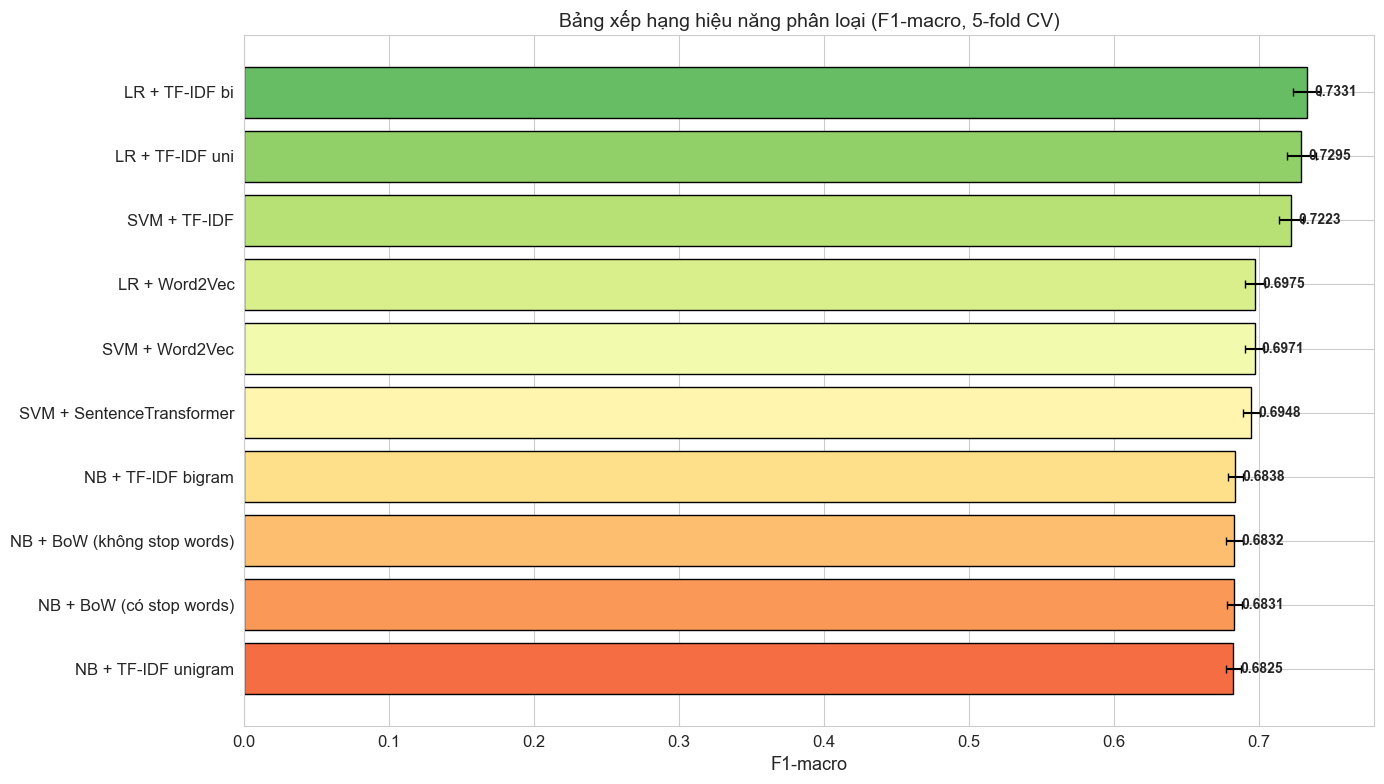

In [44]:
# Trực quan hóa bảng xếp hạng
fig, ax = plt.subplots(figsize=(14, 8))

methods_sorted = results_df['Method'].tolist()[::-1]
f1_sorted = results_df['F1-macro'].tolist()[::-1]
std_sorted = results_df['Std'].tolist()[::-1]

colors_rank = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(methods_sorted)))
bars = ax.barh(methods_sorted, f1_sorted, xerr=std_sorted, color=colors_rank,
               edgecolor='black', capsize=3)
ax.set_xlabel('F1-macro', fontsize=13)
ax.set_title(
    'Bảng xếp hạng hiệu năng phân loại (F1-macro, 5-fold CV)', fontsize=14)

for bar, v in zip(bars, f1_sorted):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.4f}',
            va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'classification_leaderboard.png',
            dpi=150, bbox_inches='tight')
plt.show()

[CHỌN] Vectorizer/Model: LR + TF-IDF bi (F1=0.7331)
KẾT QUẢ MÔ HÌNH ĐỨNG ĐẦU LEADERBOARD (LR + TF-IDF bi)
Đánh giá trên tập TEST gốc (80/20 split)
(Lưu ý: CM dùng split 80/20 để trực quan hóa;
 F1-macro trong leaderboard phía trên dùng 5-fold CV)

Accuracy:  0.7639
F1-macro:  0.7438

Classification Report:
              precision    recall  f1-score   support

   Supported       0.73      0.92      0.82      2025
Hallucinated       0.84      0.56      0.67      1533

    accuracy                           0.76      3558
   macro avg       0.79      0.74      0.74      3558
weighted avg       0.78      0.76      0.75      3558



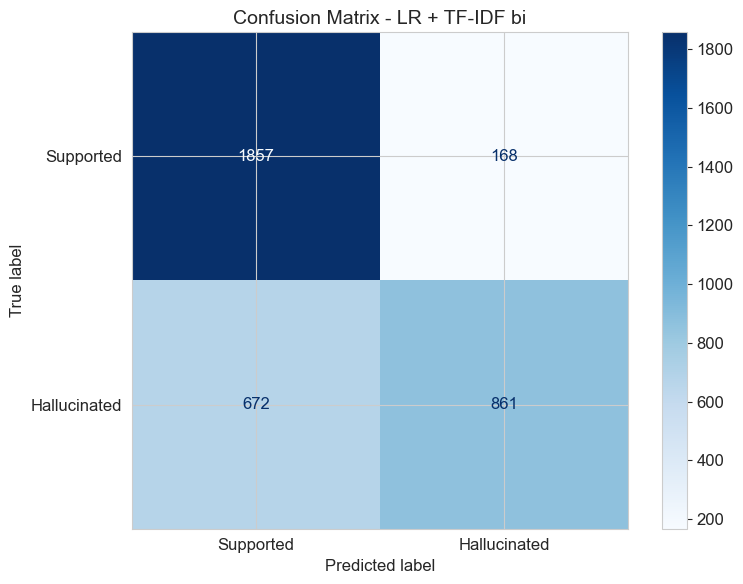

In [45]:
# Confusion Matrix cho mô hình đứng đầu leaderboard (train 80%, evaluate 20%)

# Chia train/test 80/20 stratified (dùng index để áp dụng nhất quán cho mọi X)
_idx_tr, _idx_te = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=SEED, stratify=y)
y_train_best = y[_idx_tr]
y_test_best = y[_idx_te]

# === QUYẾT ĐỊNH 4: VECTORIZER (theo leaderboard) ===
best_method = results_df.iloc[0]['Method']
print(
    f"[CHỌN] Vectorizer/Model: {best_method} (F1={results_df.iloc[0]['F1-macro']:.4f})")

if best_method == 'LR + TF-IDF bi':
    X_train_best = X_tfidf_bi[_idx_tr]
    X_test_best = X_tfidf_bi[_idx_te]
    X_final_all = X_tfidf_bi
    best_model = LogisticRegression(max_iter=1000, random_state=SEED)
elif best_method == 'LR + TF-IDF uni':
    X_train_best = X_tfidf_uni[_idx_tr]
    X_test_best = X_tfidf_uni[_idx_te]
    X_final_all = X_tfidf_uni
    best_model = LogisticRegression(max_iter=1000, random_state=SEED)
elif best_method == 'SVM + TF-IDF':
    X_train_best = X_tfidf_uni[_idx_tr]
    X_test_best = X_tfidf_uni[_idx_te]
    X_final_all = X_tfidf_uni
    best_model = LinearSVC(max_iter=5000, random_state=SEED)
elif best_method == 'SVM + SentenceTransformer':
    X_train_best = X_st[_idx_tr]
    X_test_best = X_st[_idx_te]
    X_final_all = X_st
    best_model = LinearSVC(max_iter=5000, random_state=SEED)
else:
    # Fallback an toàn
    X_train_best = X_tfidf_bi[_idx_tr]
    X_test_best = X_tfidf_bi[_idx_te]
    X_final_all = X_tfidf_bi
    best_model = LogisticRegression(max_iter=1000, random_state=SEED)

best_model.fit(X_train_best, y_train_best)
y_pred = best_model.predict(X_test_best)

print("=" * 60)
print(f"KẾT QUẢ MÔ HÌNH ĐỨNG ĐẦU LEADERBOARD ({best_method})")
print("Đánh giá trên tập TEST gốc (80/20 split)")
print("(Lưu ý: CM dùng split 80/20 để trực quan hóa;")
print(" F1-macro trong leaderboard phía trên dùng 5-fold CV)")
print("=" * 60)
print(f"\nAccuracy:  {accuracy_score(y_test_best, y_pred):.4f}")
print(f"F1-macro:  {f1_score(y_test_best, y_pred, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_best, y_pred,
      target_names=['Supported', 'Hallucinated']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test_best, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Supported', 'Hallucinated'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {best_method}', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix_best.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## 5. KẾT LUẬN

### 5.1. Tóm tắt kết quả

| Mục | Kết quả |
|------|--------|
| **Dataset** | RAGTruth (~18,000 mẫu, 2 nhãn: Supported/Hallucinated) |
| **Text EDA** | Phân phối độ dài khác biệt giữa 2 nhóm (Mann-Whitney U test); có xu hướng Zipf nhưng lệch khỏi Zipf lý tưởng (\(\alpha\) xa 1) |
| **Tokenization** | BPE cân bằng tốt giữa vocab size và OOV rate |
| **Stop words** | Đã báo cáo đầy đủ: giảm vocab/tokens, **MI mean trước-sau**, và **NB F1 trước-sau**; kết quả cho thấy bỏ stop words không luôn cải thiện đáng kể |
| **Stemming/Lemmatization** | Porter, Snowball, WordNet đều được triển khai; collision + LR 5-fold được đối chiếu định lượng |
| **Vectorization** | BoW + TF-IDF (1-gram, 1-2gram, 1-2-3gram) được **cài đặt thủ công**; Word2Vec dense; có cosine + t-SNE + silhouette |
| **Ablation** | Có bảng `PREPROCESS_LENGTH_ABLATION` (tác động đến độ dài qua từng bước) và `ABLATION_SUMMARY` (đối chiếu Requirement §2) |
| **Best model** | Theo leaderboard: LR + TF-IDF bi đạt F1-macro cao nhất |

### 5.2. Nhận xét

1. **Tiền xử lý quan trọng**: Chuẩn hóa + stop words + lemmatization làm thay đổi rõ phân phối độ dài và không gian đặc trưng.
2. **Dense vs Sparse**: Trên tập này, TF-IDF (đặc biệt bi-gram) vượt Word2Vec/Sentence Transformer với mô hình tuyến tính.
3. **Không có quy tắc tuyệt đối**: Bỏ stop words và dùng embedding dense không luôn thắng; cần kiểm chứng bằng MI/F1/silhouette cụ thể.
4. **Tính tái lập**: Các chỉ số chính đều được lưu biến và có thể đối chiếu trực tiếp trong bảng ablation.

### 5.3. Hạn chế và hướng phát triển

- **Mất cân bằng nhãn**: Có thể áp dụng SMOTE hoặc class weighting để cải thiện.
- **Domain-specific preprocessing**: Có thể thêm xử lý riêng cho cấu trúc RAG (query/context/output) thay vì chỉ dùng `output`.
- **Mô hình mạnh hơn**: Fine-tuning Transformer chuyên biệt có thể tăng thêm chất lượng phân loại.

In [46]:
# Lưu dữ liệu đã xử lý

df_save = df[['id', 'text', 'text_normalized', 'text_processed', 'label', 'label_name',
              'task_type', 'model', 'text_len_char', 'text_len_words', 'text_len_sents', 'ttr']].copy()
df_save.to_csv(OUTPUT_DIR / 'ragtruth_processed.csv', index=False)
print(f"Saved processed text: {df_save.shape} → ragtruth_processed.csv")

# Lưu feature matrix tốt nhất (dựa trên QUYẾT ĐỊNH 4)
if hasattr(X_final_all, 'toarray'):  # sparse (TF-IDF)
    sp_io.save_npz(str(OUTPUT_DIR / 'X_processed_best.npz'),
                   X_final_all.tocsr())
    print(
        f"Saved feature matrix (sparse): X_processed_best.npz {X_final_all.shape}")
else:  # dense (Word2Vec / SentenceTransformer)
    np.save(str(OUTPUT_DIR / 'X_processed_best.npy'), X_final_all)
    print(
        f"Saved feature matrix (dense): X_processed_best.npy {X_final_all.shape}")

# Lưu labels
np.save(str(OUTPUT_DIR / 'y_labels.npy'), y)
print(f"Saved labels: y_labels.npy shape={y.shape}")

# Lưu metadata pipeline (các quyết định đã chọn)
pipeline_choices = {
    'decision_1_tokenizer': CHOSEN_TOKENIZER,
    'decision_2_stopwords': CHOSEN_STOPWORDS,
    'decision_3_stemlem': BEST_STEMLEM,
    'decision_4_vectorizer': best_method,
    'X_shape': list(X_final_all.shape),
    'n_classes': int(len(np.unique(y))),
    'label_map': {str(k): v for k, v in enumerate(df['label_name'].unique())},
}
with open(OUTPUT_DIR / 'pipeline_choices.json', 'w', encoding='utf-8') as _f:
    _json.dump(pipeline_choices, _f, indent=2, ensure_ascii=False)
print(f"Saved pipeline choices: pipeline_choices.json")
print(f"  {pipeline_choices}")
print("\n=== NOTEBOOK HOÀN TẤT ===")

Saved processed text: (17790, 12) → ragtruth_processed.csv


Saved feature matrix (sparse): X_processed_best.npz (17790, 10000)
Saved labels: y_labels.npy shape=(17790,)
Saved pipeline choices: pipeline_choices.json
  {'decision_1_tokenizer': 'Word-level', 'decision_2_stopwords': 'remove', 'decision_3_stemlem': 'None (baseline)', 'decision_4_vectorizer': 'LR + TF-IDF bi', 'X_shape': [17790, 10000], 'n_classes': 2, 'label_map': {'0': 'Supported', '1': 'Hallucinated'}}

=== NOTEBOOK HOÀN TẤT ===
